### Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.utils import resample

In [11]:
# Ruta donde están los archivos
ruta = r"C:\Users\fabil\Downloads"
#Hola esto es una prueba

# Archivos
archivos_clientes = [
    "TC1_06_2025_CELSIA_VALLE_V2.csv",
    "TC1_07_2025_CELSIA_VALLE_V2.csv",
    "TC1_08_2025_CELSIA_VALLE_V2.csv"
]

archivos_indicadores = [
    "Compensacion_2025_06.csv",
    "Compensacion_2025_07.csv",
    "Compensacion_2025_08.csv"
]

# --- Cargar bases de CLIENTES ---
clientes = pd.concat(
    [
        pd.read_csv(
            os.path.join(ruta, archivo),
            sep=',',
            encoding='utf-8',
            dtype={"NIU": str},          
            low_memory=False
        ).assign(archivo_origen=archivo)  
        for archivo in archivos_clientes
    ],
    ignore_index=True
)
clientes["tipo_base"] = "clientes"       

# --- Cargar bases de INDICADORES ---
indicadores = pd.concat(
    [
        pd.read_csv(
            os.path.join(ruta, archivo),
            sep=';',
            encoding='utf-8',
            dtype={"NIU": str},
            low_memory=False
        ).assign(archivo_origen=archivo)
        for archivo in archivos_indicadores
    ],
    ignore_index=True
)
indicadores["tipo_base"] = "indicadores"

# --- Limpieza de nombres de columnas ---
clientes.columns = clientes.columns.str.strip().str.upper().str.replace(" ", "_")
indicadores.columns = indicadores.columns.str.strip().str.upper().str.replace(" ", "_")

# --- Unión por NIU ---
#df_integrado = pd.merge(indicadores, clientes, on="NIU", how="inner")

# --- Resumen final ---
#print("Registros integrados:", df_integrado.shape[0])
#print("Columnas totales:", df_integrado.shape[1])
#print("Ejemplo de NIU:", df_integrado["NIU"].head(5))

# --- Guardar el dataset unificado ---
#df_integrado.to_csv(os.path.join(ruta, "Dataset_Integrado_Compensaciones.csv"), index=False, encoding='utf-8')


In [13]:
clientes

,NIU,CODIGO_CONEXION,TIPO_CONEXION,NIVEL_TENSION,NIVEL_TENSIÓN_PRIMARIA,PORC_PROP_ACTIV,CONEXION_RED,ID_COMERCIALIZADOR,ID_MERCADO,GRUPO_CALIDAD,...,AUTOGENERADOR,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,ARCHIVO_ORIGEN,TIPO_BASE
0,1000001,65011835,2,1,2,100,1,536,561,12,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_06_2025_CELSIA_VALLE_V2.csv,clientes
1,1000005,65034157,2,1,2,100,1,536,561,32,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_06_2025_CELSIA_VALLE_V2.csv,clientes
2,1000008,65034157,2,1,2,100,1,536,561,32,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_06_2025_CELSIA_VALLE_V2.csv,clientes
3,1000009,65034157,2,1,2,100,1,536,561,32,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_06_2025_CELSIA_VALLE_V2.csv,clientes
4,1000011,65034157,2,1,2,100,1,536,561,32,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_06_2025_CELSIA_VALLE_V2.csv,clientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2202237,4085956,65722646,2,1,2,100,1,62371,561,21,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2202238,20230002879,65006411,2,1,2,100,1,62371,561,11,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2202239,28003630115,65030701,2,3,0,101,1,62371,561,11,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2202240,28003630171,65030701,2,3,0,101,1,62371,561,11,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes


In [12]:
clientes.columns

Index(['NIU', 'CODIGO_CONEXION', 'TIPO_CONEXION', 'NIVEL_TENSION',
       'NIVEL_TENSIÓN_PRIMARIA', 'PORC_PROP_ACTIV', 'CONEXION_RED',
       'ID_COMERCIALIZADOR', 'ID_MERCADO', 'GRUPO_CALIDAD',
       'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA', 'COD_TRANSFORMADOR',
       'COD_DANE', 'UBICACION', 'DIRECCION', 'COND_ESPEC', 'TIPO_AREA_ESPEC',
       'COD_AREA_ESPEC', 'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD',
       'AUTOGENERADOR', 'EXP_ENERGIA', 'CAPAC_AUTOGEN', 'TIP_GENERACION',
       'COD_FRONTERA_EXPORT', 'F_ENTRADA_GENERAR', 'CONTR_RESPALDO',
       'CAPAC_CONTR_RES', 'ARCHIVO_ORIGEN', 'TIPO_BASE'],
      dtype='object')

In [6]:
print(clientes)

                 NIU  CODIGO_CONEXION  TIPO_CONEXION  NIVEL_TENSION  \
0            2896755         65030128              2              1   
1            3518981         65005423              2              1   
2        20230321850  129000000919116              2              1   
3            2949132         65005489              2              1   
4            3213681         65724288              2              1   
...              ...              ...            ...            ...   
1469982      4085956         65722646              2              1   
1469983  20230002879         65006411              2              1   
1469984  28003630115         65030701              2              3   
1469985  28003630171         65030701              2              3   
1469986  30868070001         65025808              2              1   

         NIVEL_TENSIÓN_PRIMARIA  PORC_PROP_ACTIV  CONEXION_RED  \
0                             2              100             1   
1              

In [14]:
indicadores

,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,GRUPO_CALIDAD,NIVEL_TENSION,CARGO_DISTRIBUCION,CONSUMO_MES,MES_FACTURADOS,DURA._INTERRUPCIONES,%_PROP._ACTIVO,ID_MERCADO,ARCHIVO_ORIGEN,TIPO_BASE
0,NO,CELSIA VALLE,2025-6,1000001,0.00,0.00000,0,0,0.0,10.25,...,12,1,398.310,166.0,1,0.00888,100,561,Compensacion_2025_06.csv,indicadores
1,NO,CELSIA VALLE,2025-6,1000005,13.29,0.00000,4,0,0.0,57.02,...,32,1,398.310,885.0,2,12.66083,100,561,Compensacion_2025_06.csv,indicadores
2,NO,CELSIA VALLE,2025-6,1000008,13.29,0.00000,4,0,0.0,57.02,...,32,1,398.310,143.0,2,12.66083,100,561,Compensacion_2025_06.csv,indicadores
3,NO,CELSIA VALLE,2025-6,1000009,13.29,0.00000,4,0,0.0,57.02,...,32,1,398.310,961.0,2,12.66083,100,561,Compensacion_2025_06.csv,indicadores
4,NO,CELSIA VALLE,2025-6,1000011,13.29,0.00000,4,0,0.0,57.02,...,32,1,398.310,305.0,2,12.66083,100,561,Compensacion_2025_06.csv,indicadores
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162832,NO,CELSIA VALLE,2025-8,9887654,5.47,0.00000,4,0,0.0,40.96,...,31,1,398.370,182.0,2,1.33277,100,561,Compensacion_2025_08.csv,indicadores
2162833,NO,CELSIA VALLE,2025-8,990920112578,13.50,2.20583,27,3,0.0,57.02,...,32,1,398.370,0.0,2,0.00916,100,561,Compensacion_2025_08.csv,indicadores
2162834,NO,CELSIA VALLE,2025-8,993320550,3.50,0.00000,3,0,0.0,40.96,...,31,1,326.865,0.0,2,0.00972,0,561,Compensacion_2025_08.csv,indicadores
2162835,NO,CELSIA VALLE,2025-8,9945573156,2.91,0.00000,3,0,0.0,40.96,...,31,1,398.370,0.0,2,3.87860,100,561,Compensacion_2025_08.csv,indicadores


=== EXPLORACIÓN DE LA BASE DE INDICADORES ===

Número de columnas numéricas reales: 18
Número de columnas categóricas: 12
Total de valores faltantes: 0

Estadísticas descriptivas de las variables numéricas:
                             count         mean            std     min  \
DIU                      2162837.0     8.748006      17.842555   0.000   
DIUM                     2162837.0     0.696442       2.896152   0.000   
FIU                      2162837.0     6.375038       7.229761   0.000   
FIUM                     2162837.0     0.482923       1.021546   0.000   
HC                       2162837.0     0.170751       1.795160   0.000   
DIUG                     2162837.0    23.199696      18.041363   0.000   
FIUG                     2162837.0    15.602879       6.527029   0.000   
VC                       2162837.0     0.066035       0.550587   0.000   
TVC                      2162837.0     0.530500       3.080222   0.000   
THC                      2162837.0     1.846394      

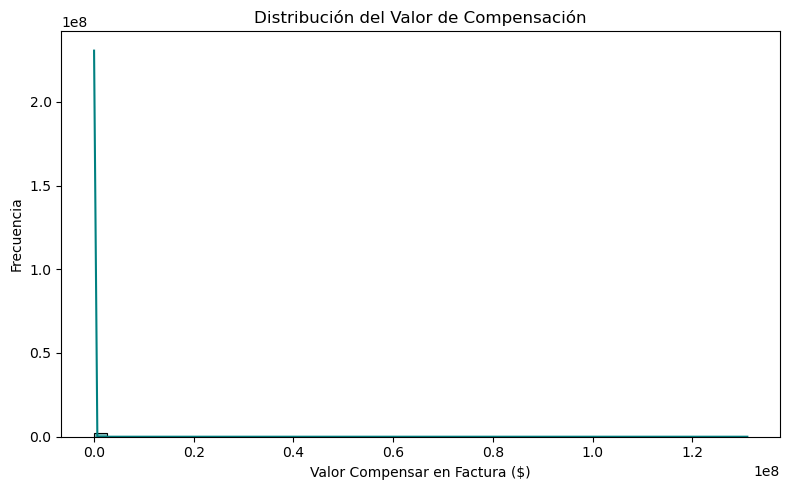

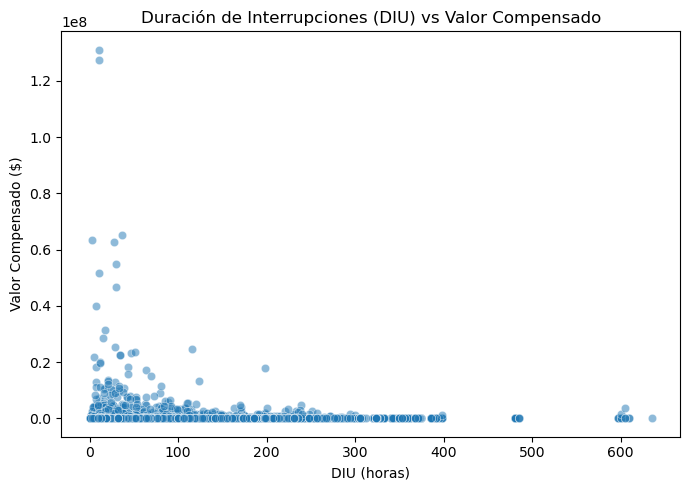

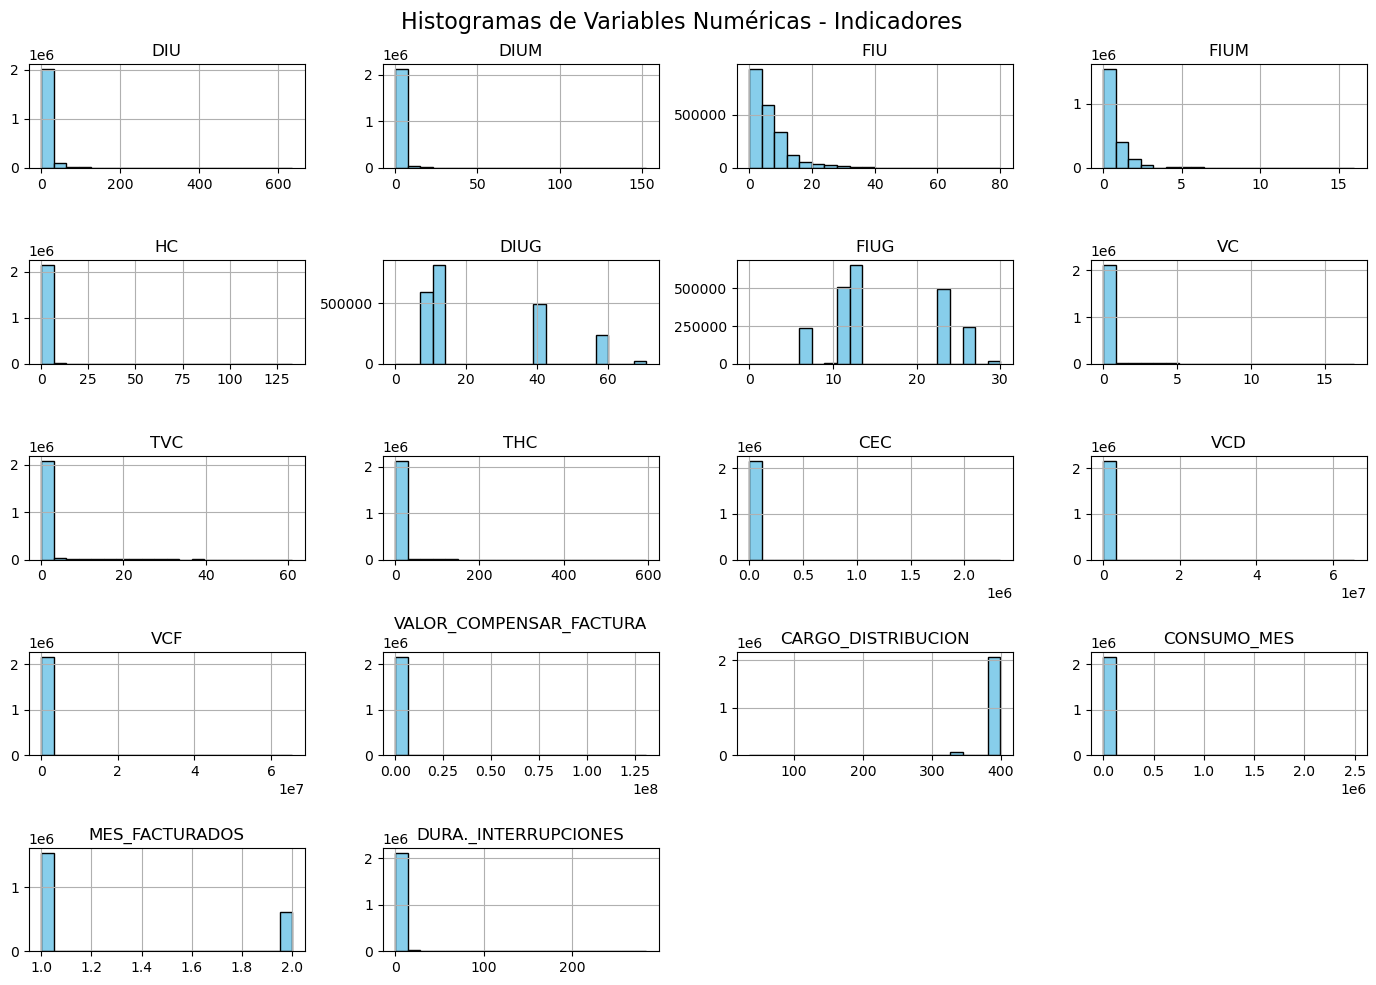


Generando gráficos de frecuencia para las variables categóricas...


C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


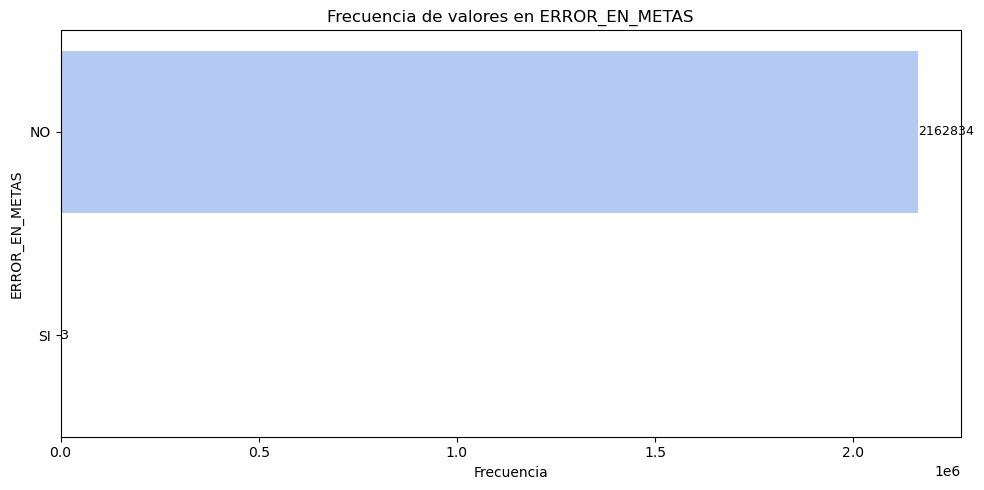

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


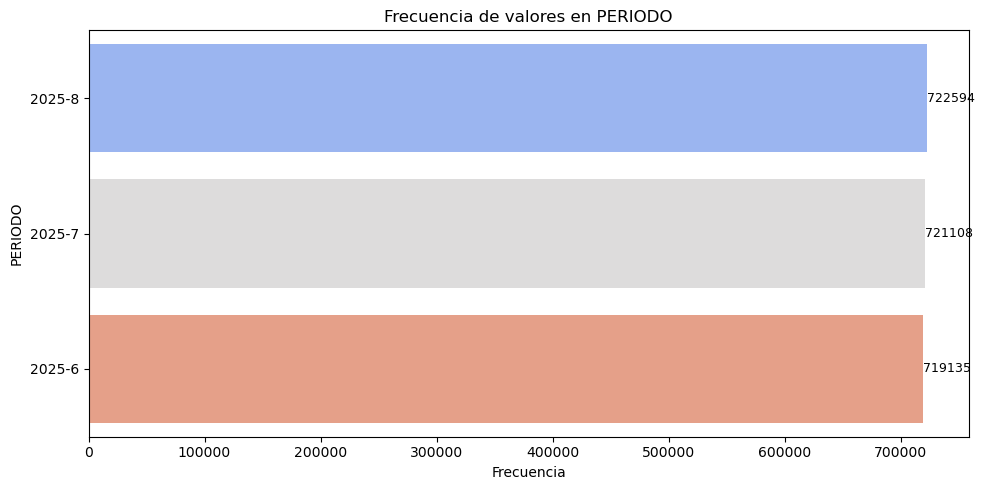

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


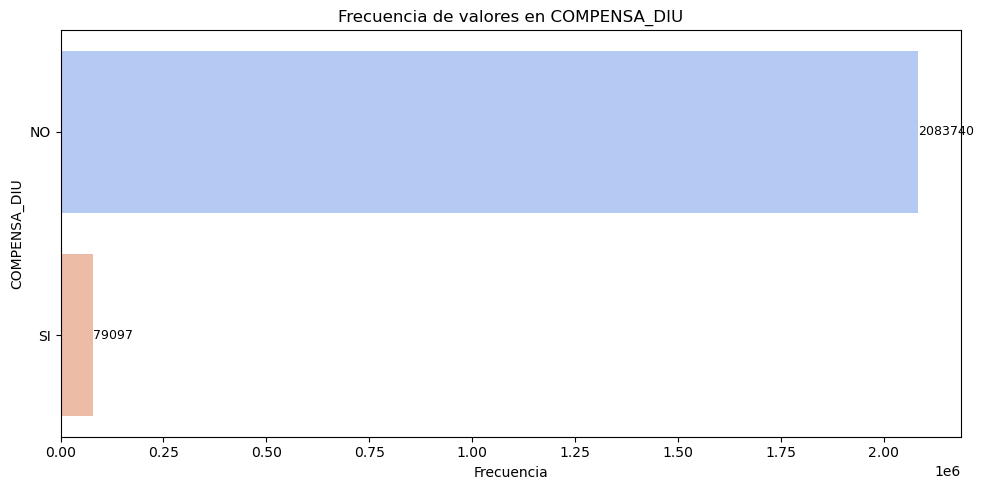

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


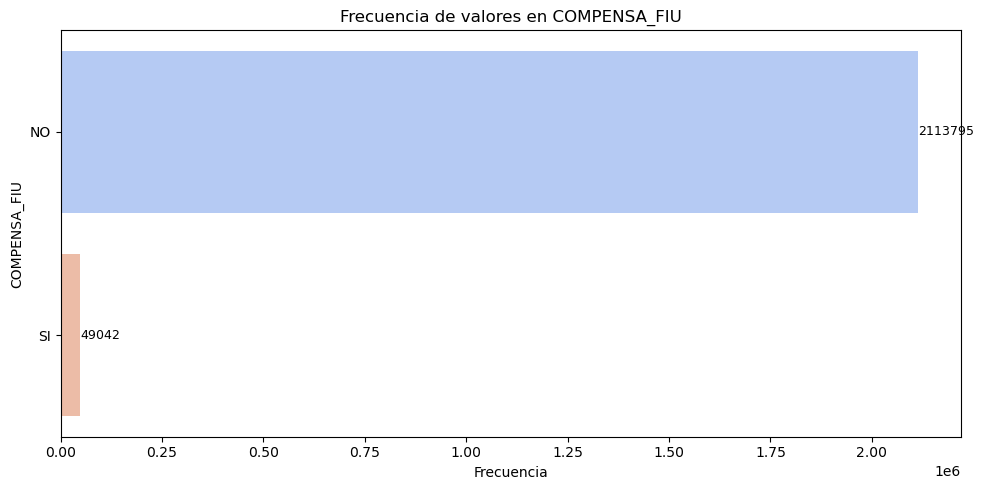

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


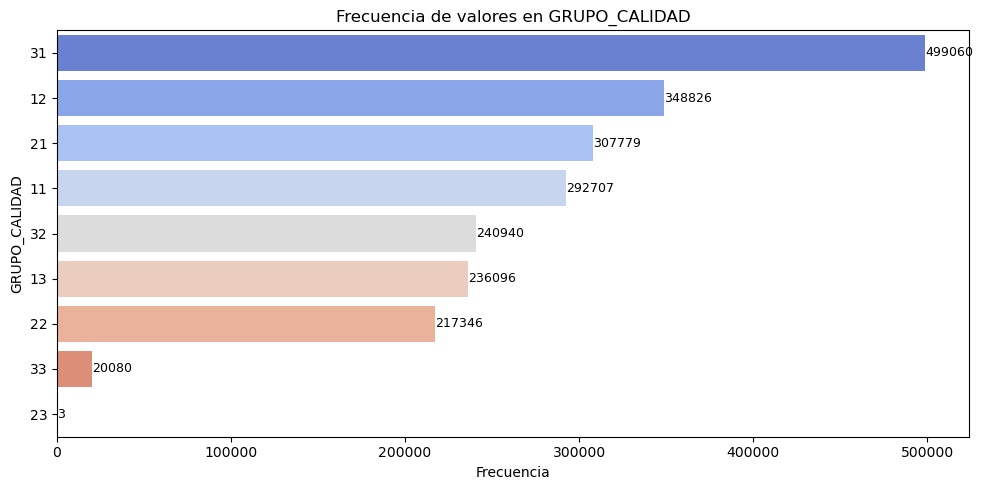

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


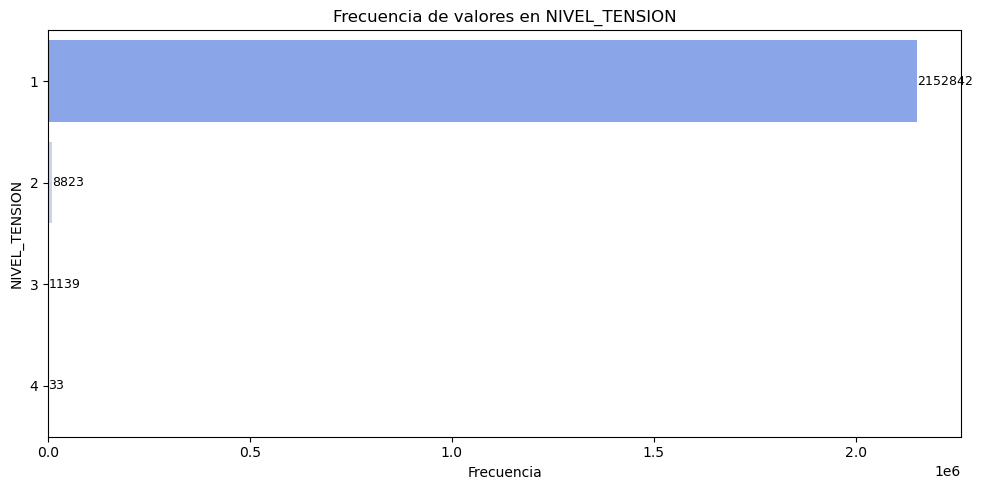

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


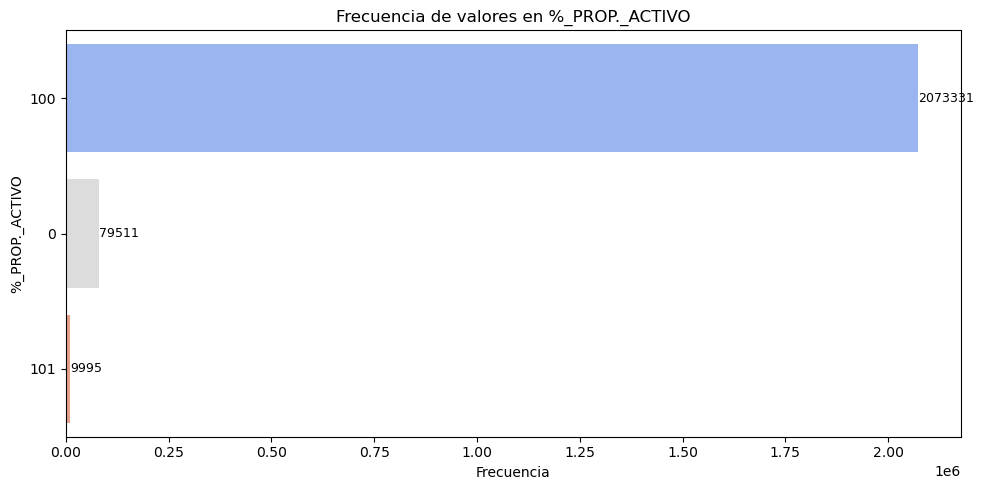

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


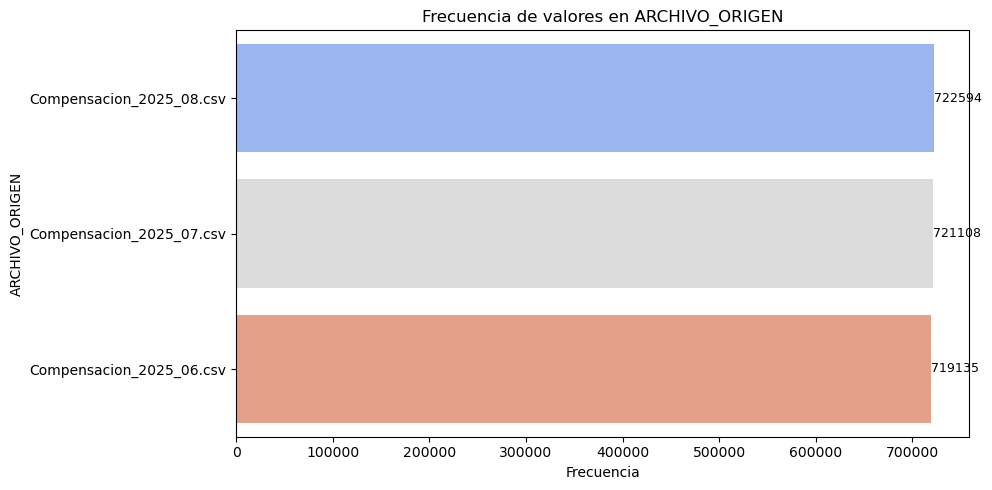

In [15]:
def explorar_indicadores(df):
    print("=== EXPLORACIÓN DE LA BASE DE INDICADORES ===\n")

    # Columnas que deben tratarse como categóricas aunque sean numéricas
    cols_categoricas = [
        'GRUPO_CALIDAD', 'NIVEL_TENSION', '%_PROP._ACTIVO', 'ID_MERCADO', 
        'OPERADOR_RED', 'PERIODO'
    ]

    # Convertirlas a tipo string si existen
    for c in cols_categoricas:
        if c in df.columns:
            df[c] = df[c].astype(str)

    # Asegurar que NIU sea string
    if 'NIU' in df.columns:
        df['NIU'] = df['NIU'].astype(str).str.strip()

    # Seleccionar variables numéricas y categóricas
    numericas = df.select_dtypes(include=['number']).columns
    categoricas = df.select_dtypes(include=['object']).columns

    # Total de valores faltantes
    faltantes = df.isnull().sum().sum()
    print(f'Número de columnas numéricas reales: {len(numericas)}')
    print(f'Número de columnas categóricas: {len(categoricas)}')
    print(f'Total de valores faltantes: {faltantes}\n')

    # Estadísticas descriptivas de las variables numéricas
    if len(numericas) > 0:
        print("Estadísticas descriptivas de las variables numéricas:")
        print(df[numericas].describe().T)
    else:
        print("No hay variables numéricas continuas para describir.\n")

    # --- Visualizaciones principales ---
    if 'VALOR_COMPENSAR_FACTURA' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['VALOR_COMPENSAR_FACTURA'].dropna(), bins=50, kde=True, color='teal')
        plt.title('Distribución del Valor de Compensación')
        plt.xlabel('Valor Compensar en Factura ($)')
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

    if 'DIU' in df.columns and 'VALOR_COMPENSAR_FACTURA' in df.columns:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x='DIU', y='VALOR_COMPENSAR_FACTURA', data=df, alpha=0.5)
        plt.title('Duración de Interrupciones (DIU) vs Valor Compensado')
        plt.xlabel('DIU (horas)')
        plt.ylabel('Valor Compensado ($)')
        plt.tight_layout()
        plt.show()

    if len(numericas) > 0:
        df[numericas].hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
        plt.suptitle('Histogramas de Variables Numéricas - Indicadores', fontsize=16)
        plt.tight_layout()
        plt.show()

    # --- Gráficos automáticos para variables categóricas ---
    print("\nGenerando gráficos de frecuencia para las variables categóricas...")
    for col in categoricas:
        if df[col].nunique() > 1 and df[col].nunique() <= 30:
            plt.figure(figsize=(10, 5))
            ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')
            plt.title(f'Frecuencia de valores en {col}')
            plt.xlabel('Frecuencia')
            plt.ylabel(col)
            for p in ax.patches:
                ancho = p.get_width()
                ax.annotate(f'{int(ancho)}', (ancho + 0.5, p.get_y() + p.get_height()/2),
                            ha='left', va='center', fontsize=9, color='black')
            plt.tight_layout()
            plt.show()

explorar_indicadores(indicadores)

=== EXPLORACIÓN DE LA BASE DE CLIENTES ===

Número de columnas numéricas reales: 1
Número de columnas categóricas: 32
Total de valores faltantes: 6594858

Estadísticas descriptivas de las variables numéricas reales:
                count       mean         std   min  25%   50%    75%     max
CAPAC_AUTOGEN  3956.0  50.681491  204.385387  0.01  5.0  12.0  100.0  6042.0


C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='NIVEL_TENSION', data=df, palette='viridis')


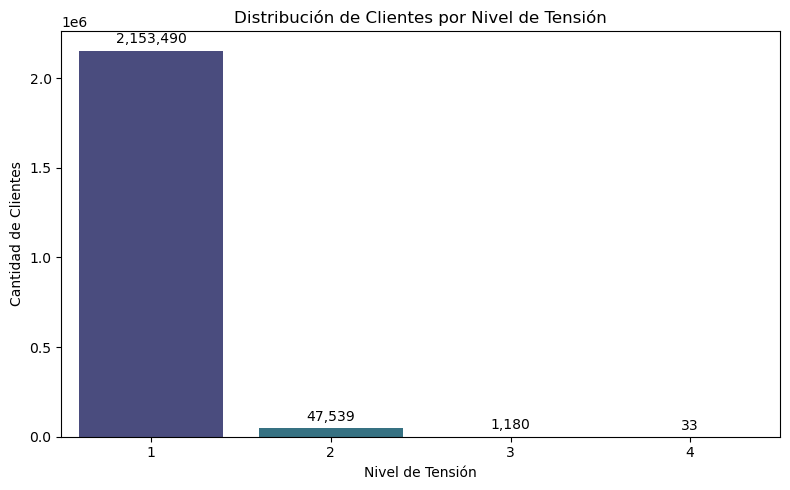

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TIPO_CONEXION', data=df, palette='Set2')


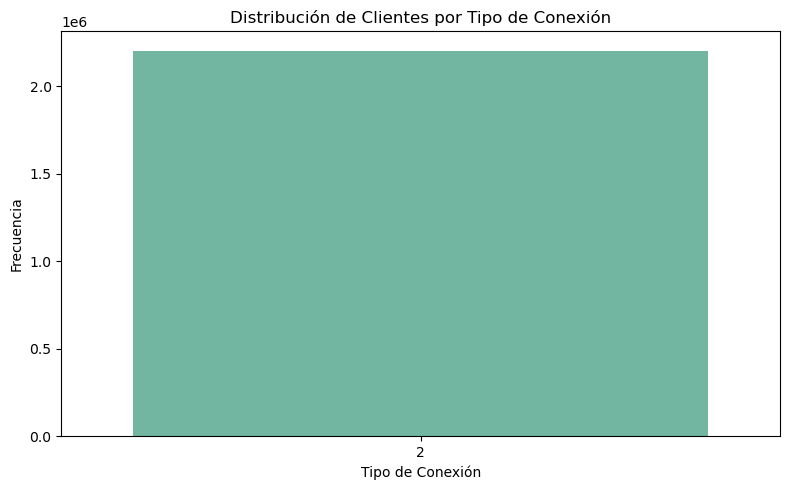

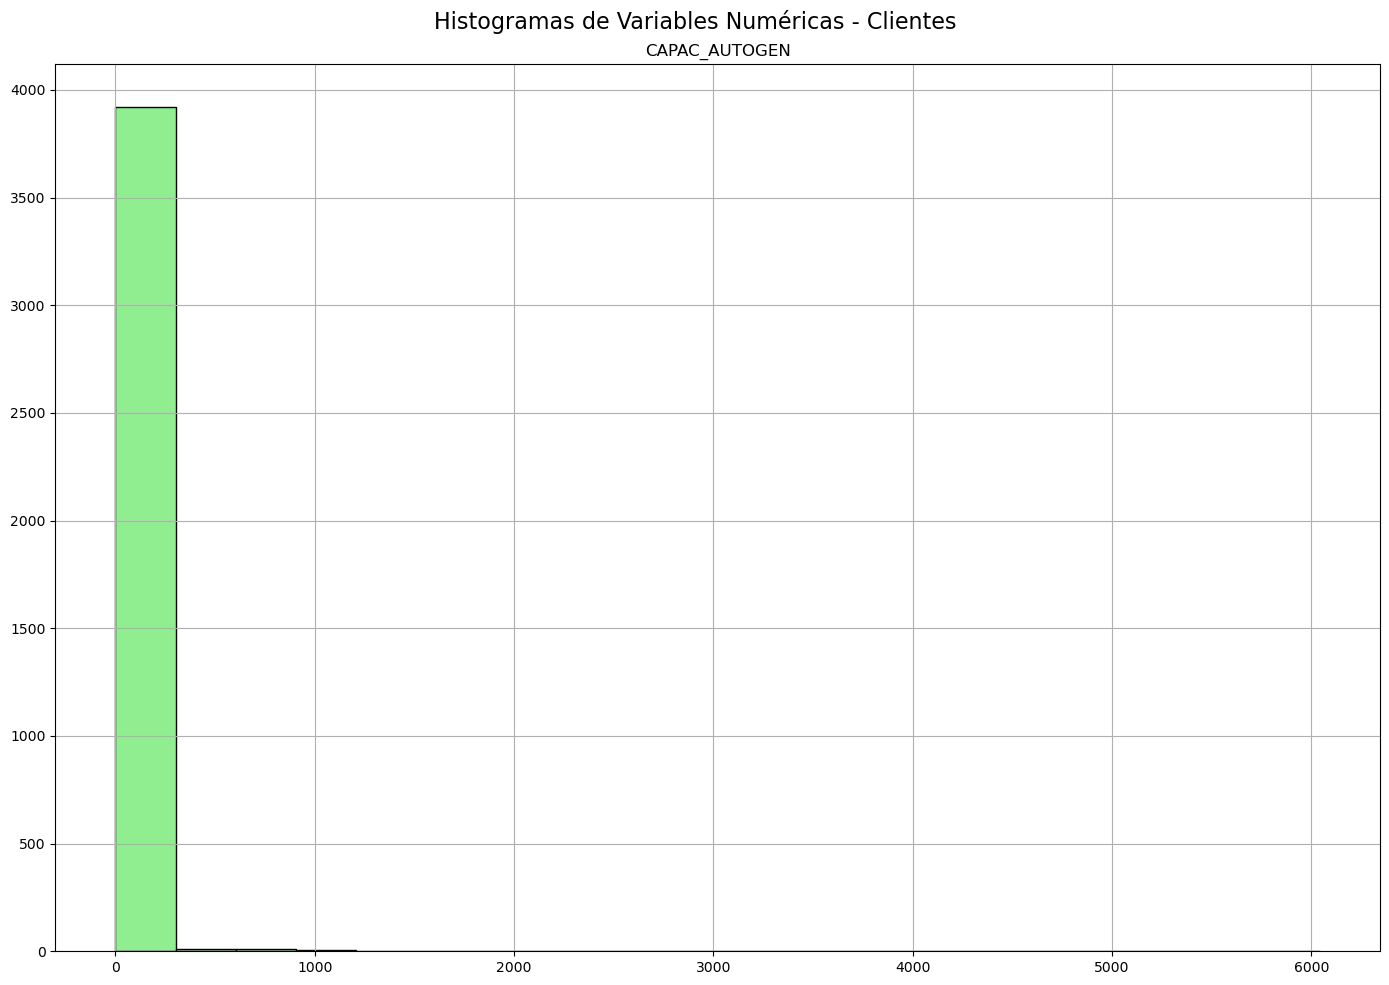


Generando gráficos de frecuencia para las variables categóricas...


C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


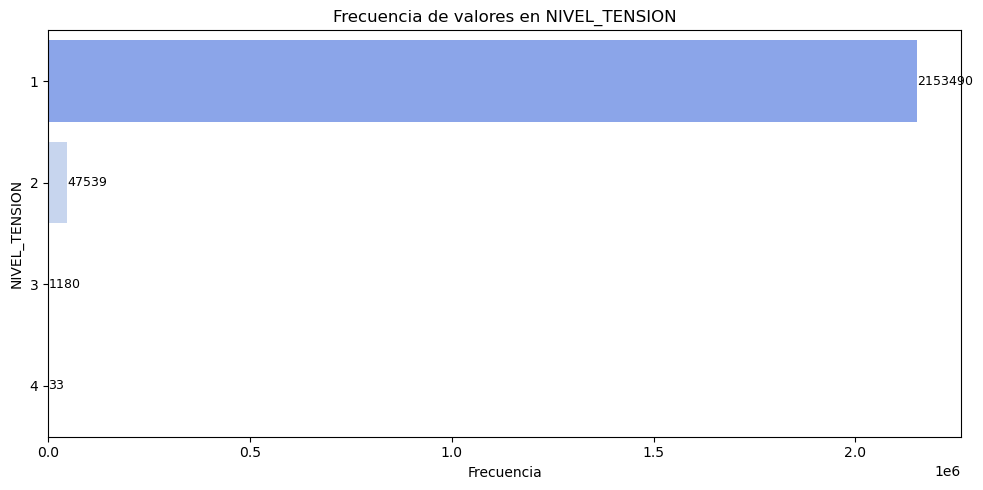

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


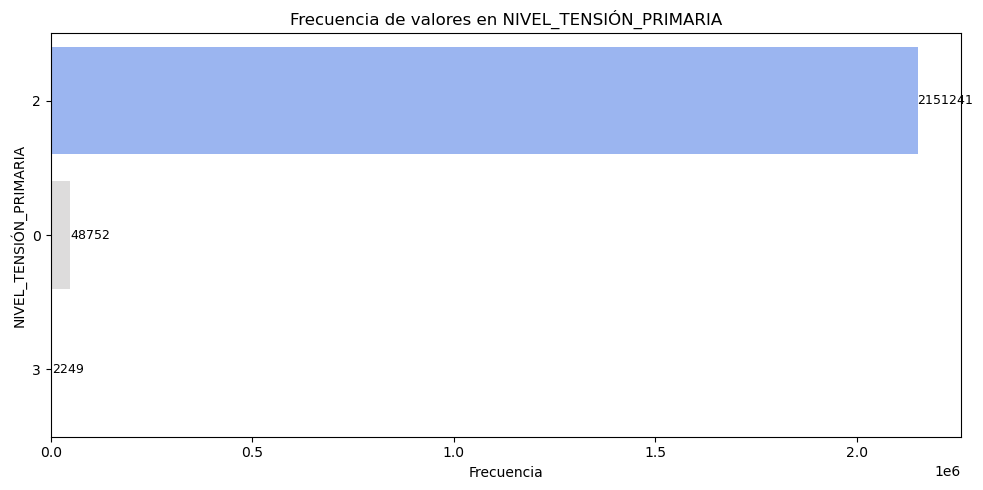

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


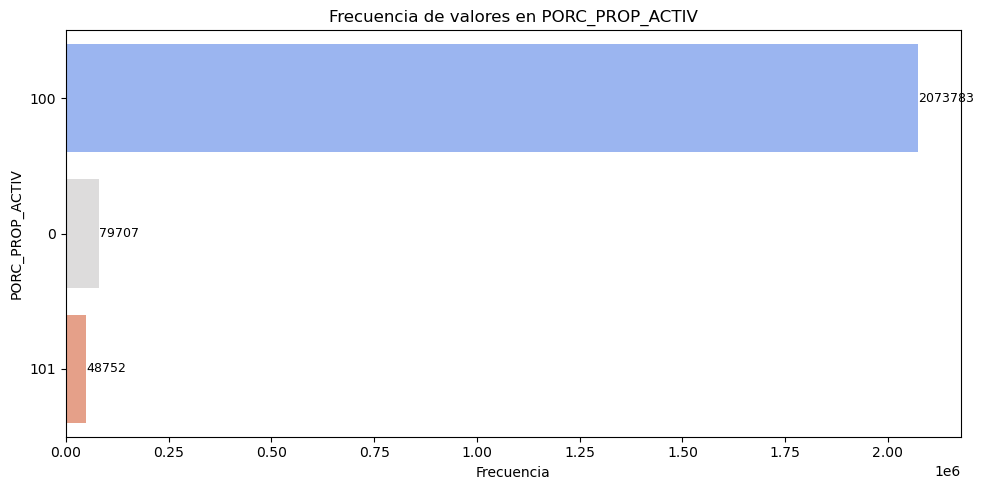

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


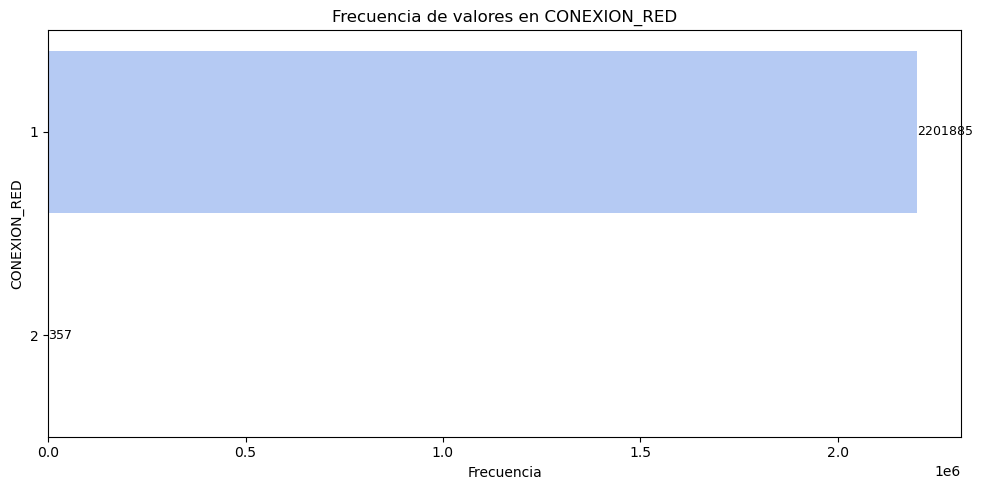

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


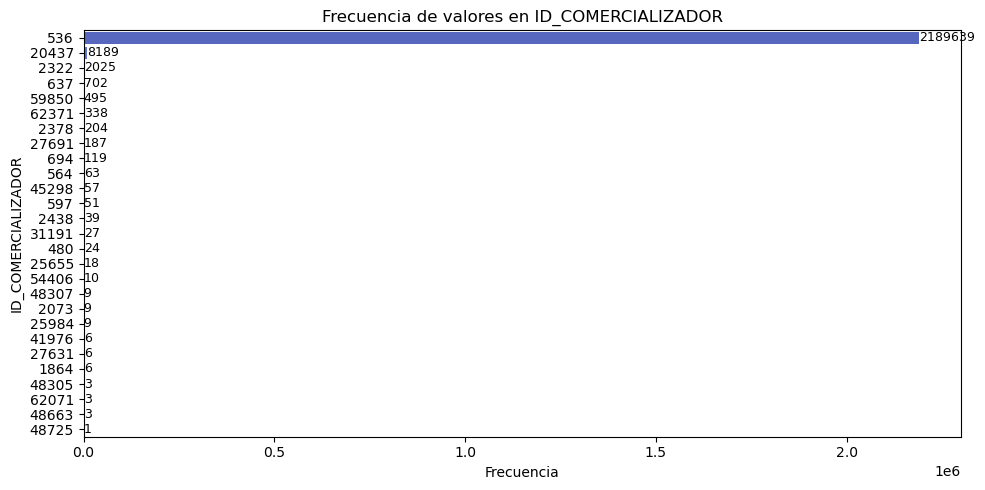

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


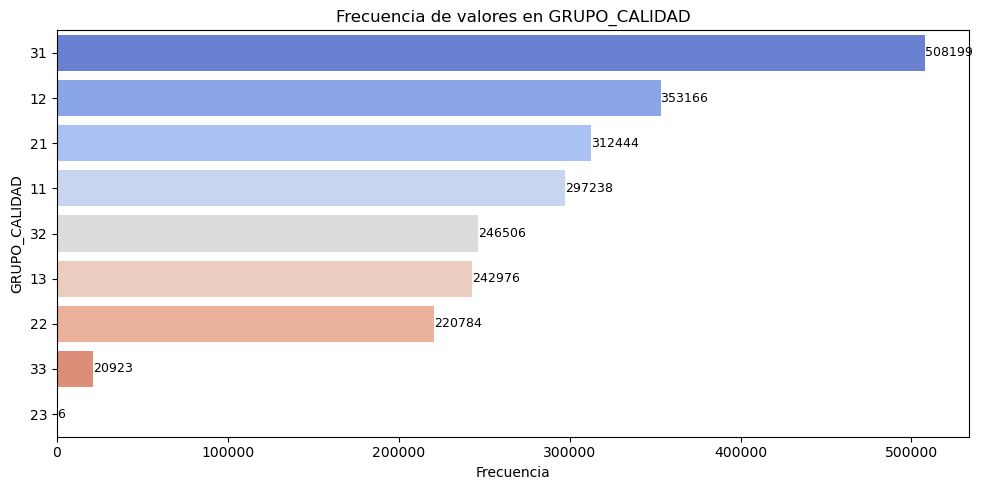

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


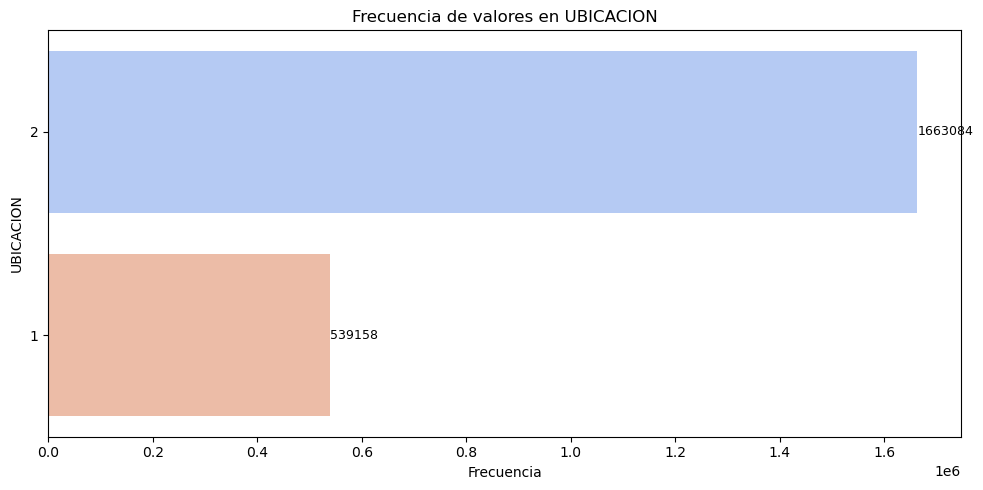

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


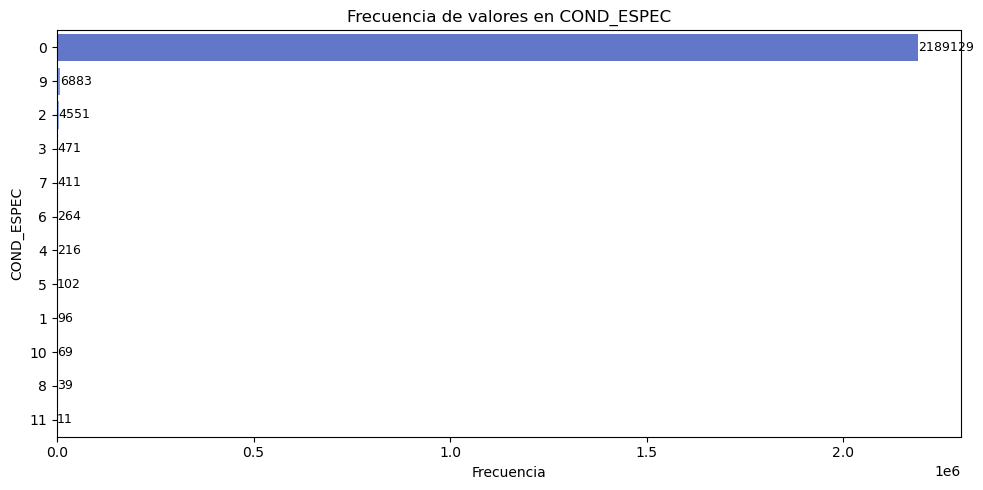

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


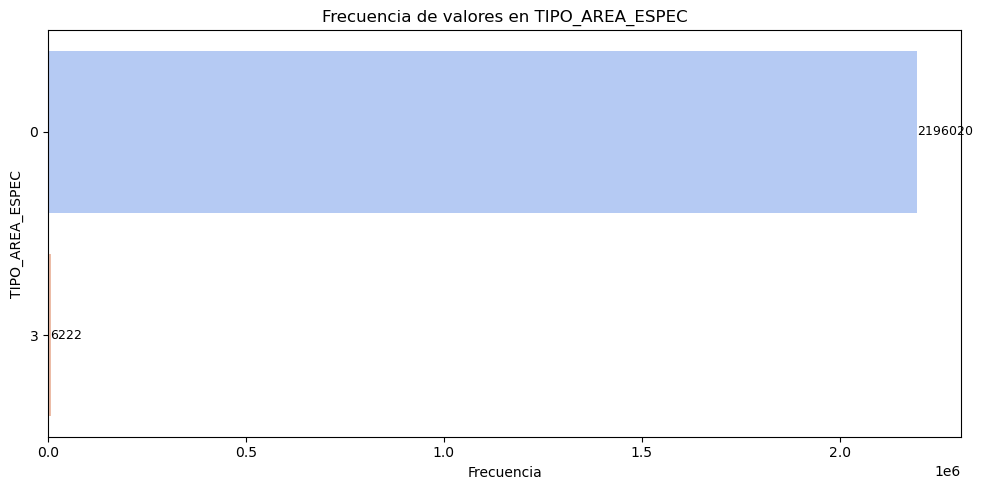

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


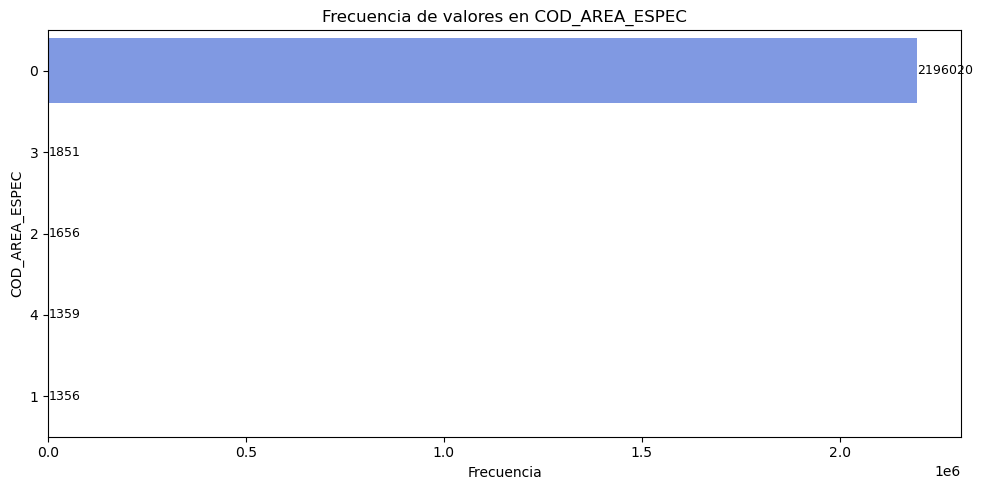

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


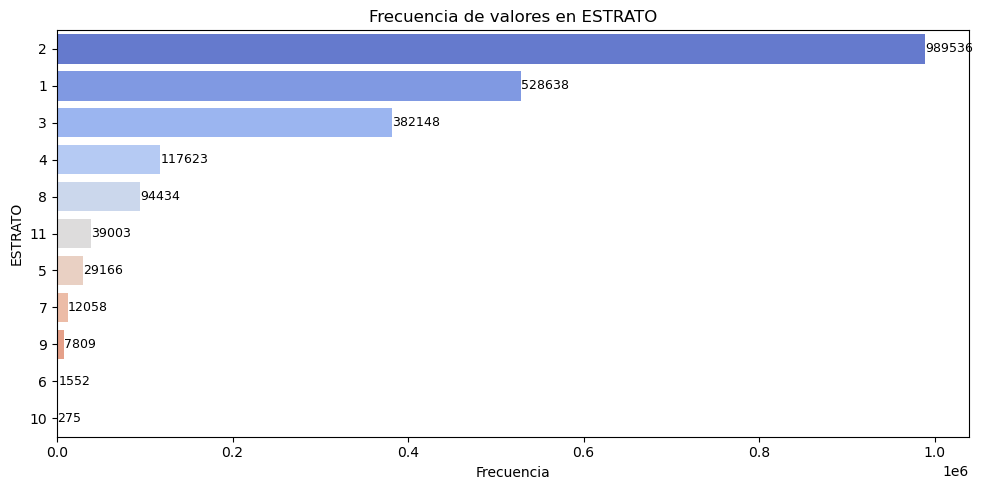

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


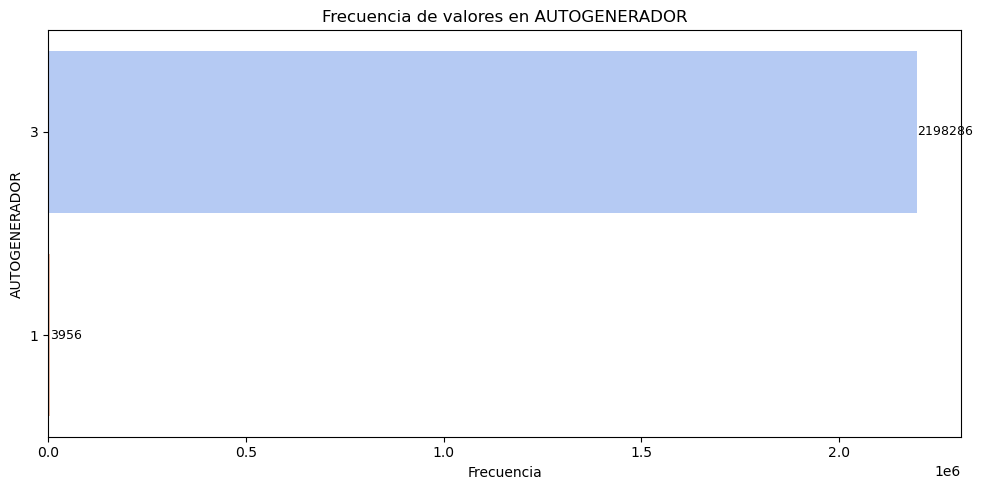

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


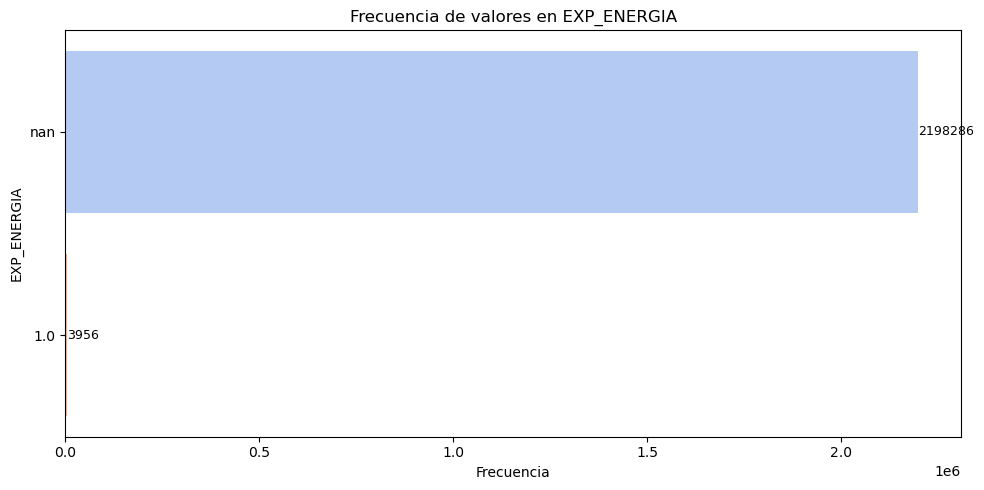

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


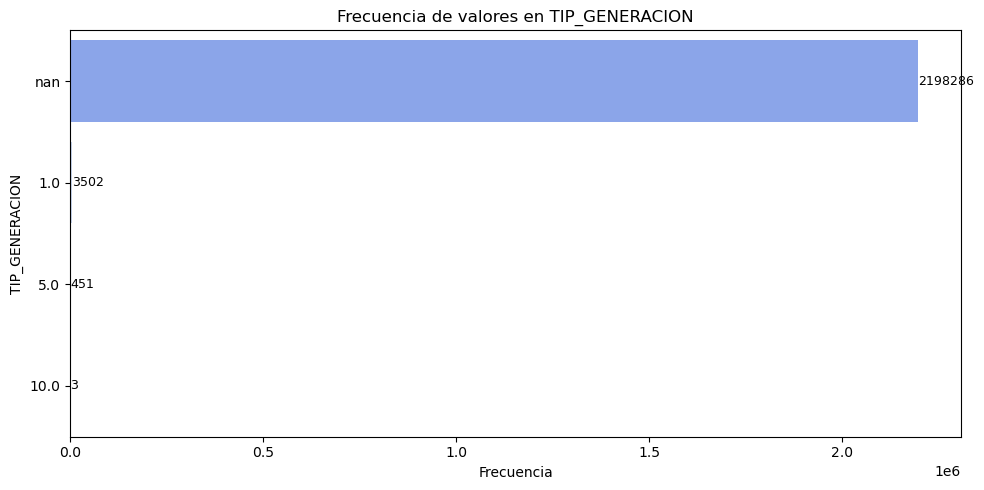

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


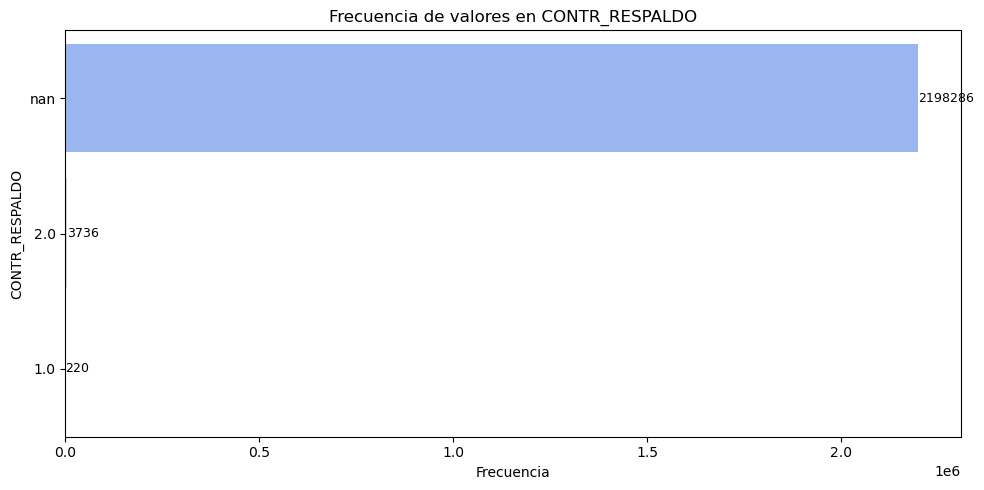

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


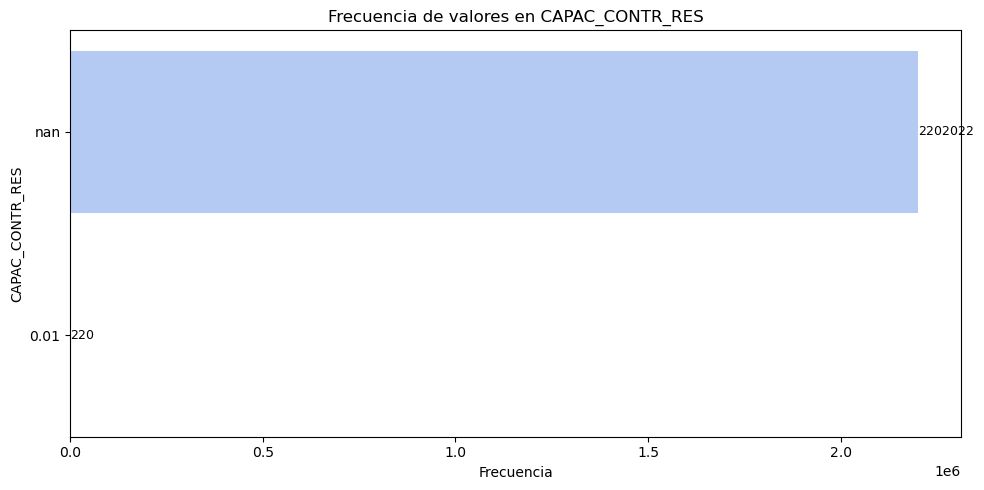

C:\Users\fabil\AppData\Local\Temp\ipykernel_19092\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


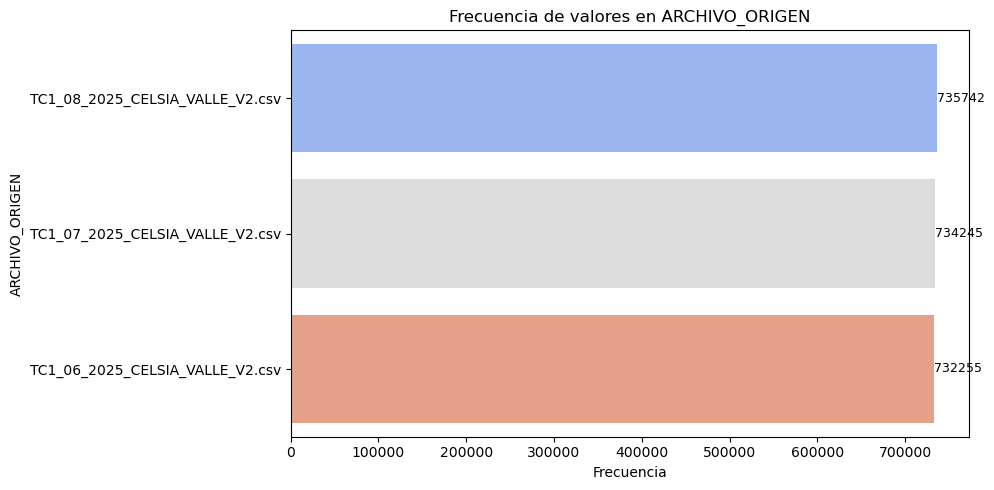

In [16]:
def explorar_clientes(df):
    print("=== EXPLORACIÓN DE LA BASE DE CLIENTES ===\n")

    # Columnas que deben tratarse como categóricas aunque sean numéricas
    cols_categoricas = [
        'TIPO_CONEXION', 'NIVEL_TENSION', 'NIVEL_TENSIÓN_PRIMARIA', 'PORC_PROP_ACTIV',
        'CONEXION_RED', 'ID_COMERCIALIZADOR', 'ID_MERCADO', 'GRUPO_CALIDAD',
        'COD_CIRCUITO_LINEA', 'COD_DANE', 'UBICACION', 'COND_ESPEC', 'TIPO_AREA_ESPEC',
        'COD_AREA_ESPEC', 'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD',
        'AUTOGENERADOR', 'EXP_ENERGIA', 'TIP_GENERACION', 'CONTR_RESPALDO', 'CAPAC_CONTR_RES'
    ]

    # Convertirlas a tipo string si existen
    for c in cols_categoricas:
        if c in df.columns:
            df[c] = df[c].astype(str)

    # Excluir las variables geográficas de las estadísticas
    excluir = ['LATITUD', 'LONGITUD', 'ALTITUD', 'ALTITUD_REAL']  # si existe

    numericas = df.select_dtypes(include=['number']).columns
    numericas = [col for col in numericas if col not in excluir]
    categoricas = df.select_dtypes(include=['object']).columns

    # Valores faltantes
    faltantes = df.isnull().sum().sum()
    print(f'Número de columnas numéricas reales: {len(numericas)}')
    print(f'Número de columnas categóricas: {len(categoricas)}')
    print(f'Total de valores faltantes: {faltantes}\n')

    # Estadísticas descriptivas
    if len(numericas) > 0:
        print("Estadísticas descriptivas de las variables numéricas reales:")
        print(df[numericas].describe().T)
    else:
        print("No hay variables numéricas continuas para describir.\n")

    # --- Visualizaciones principales ---
    if 'NIVEL_TENSION' in df.columns:
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x='NIVEL_TENSION', data=df, palette='viridis')
        plt.title('Distribución de Clientes por Nivel de Tensión')
        plt.xlabel('Nivel de Tensión')
        plt.ylabel('Cantidad de Clientes')
        for p in ax.patches:
            ax.annotate(f'{p.get_height():,.0f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                        textcoords='offset points')
        plt.tight_layout()
        plt.show()

    if 'TIPO_CONEXION' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(x='TIPO_CONEXION', data=df, palette='Set2')
        plt.title('Distribución de Clientes por Tipo de Conexión')
        plt.xlabel('Tipo de Conexión')
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

    # Histogramas de variables numéricas
    if len(numericas) > 0:
        df[numericas].hist(bins=20, figsize=(14, 10), color='lightgreen', edgecolor='black')
        plt.suptitle('Histogramas de Variables Numéricas - Clientes', fontsize=16)
        plt.tight_layout()
        plt.show()

    # --- NUEVO BLOQUE: Gráficos automáticos para todas las categóricas ---
    print("\nGenerando gráficos de frecuencia para las variables categóricas...")
    for col in categoricas:
        # Solo graficar si el número de categorías es razonable (<30)
        if df[col].nunique() > 1 and df[col].nunique() <= 30:
            plt.figure(figsize=(10, 5))
            ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')
            plt.title(f'Frecuencia de valores en {col}')
            plt.xlabel('Frecuencia')
            plt.ylabel(col)
            for p in ax.patches:
                ancho = p.get_width()
                ax.annotate(f'{int(ancho)}', (ancho + 0.5, p.get_y() + p.get_height()/2),
                            ha='left', va='center', fontsize=9, color='black')
            plt.tight_layout()
            plt.show()

explorar_clientes(clientes)

In [18]:
# Valores faltantes en la base de clientes
faltantes_clientes = (
    clientes.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Columna', 0: 'Valores_Faltantes'})
)
faltantes_clientes

,Columna,Valores_Faltantes
0,NIU,0
1,CODIGO_CONEXION,0
2,TIPO_CONEXION,0
3,NIVEL_TENSION,0
4,NIVEL_TENSIÓN_PRIMARIA,0
5,PORC_PROP_ACTIV,0
6,CONEXION_RED,0
7,ID_COMERCIALIZADOR,0
8,ID_MERCADO,0
9,GRUPO_CALIDAD,0


In [19]:
# Columnas con valores faltantes masivos (relacionadas con autogeneración)
cols_a_eliminar = [
    "EXP_ENERGIA",
    "CAPAC_AUTOGEN",
    "TIP_GENERACION",
    "COD_FRONTERA_EXPORT",
    "F_ENTRADA_GENERAR",
    "CONTR_RESPALDO",
    "CAPAC_CONTR_RES"
]

# Crear nueva base limpia
clientes_limpia = clientes.drop(columns=cols_a_eliminar).reset_index(drop=True)

# Confirmar resultados
print("=== Limpieza completada ===")
print(f"Filas totales: {len(clientes_limpia):,}")
print(f"Columnas antes: {clientes.shape[1]}  →  después: {clientes_limpia.shape[1]}")
print("Columnas eliminadas:", cols_a_eliminar)

=== Limpieza completada ===
Filas totales: 2,202,242
Columnas antes: 33  →  después: 26
Columnas eliminadas: ['EXP_ENERGIA', 'CAPAC_AUTOGEN', 'TIP_GENERACION', 'COD_FRONTERA_EXPORT', 'F_ENTRADA_GENERAR', 'CONTR_RESPALDO', 'CAPAC_CONTR_RES']


### Unión clientes vs indicadores

Dado que un cliente puede aparecer más de una vez en el df de clientes, sin embargo este aparecerá una sola vez en el de indicadores, se toma como referencia el df de indicadores y se hace el merge con clientes, pero dejando la info solo del primer registro.

Este ajuste se hace dado que un cliente puede cambiar de comercializador en un mes y cuando esto pasa se registra dos veces en el df clientes, sin embargo sus indicadores siguen siendo los mismos.

In [ ]:
# --- Eliminar duplicados en clientes por NIU y PERIODO ---
clientes_dedup = clientes.drop_duplicates(subset=['NIU', 'PERIODO'], keep='first')

print(f"Clientes originales: {len(clientes):,}")
print(f"Clientes sin duplicados (NIU + PERIODO): {len(clientes_dedup):,}")

# --- Merge: base principal = indicadores ---
df_merged = pd.merge(
    indicadores,
    clientes_dedup,
    how='left',  # mantiene todos los registros de indicadores
    on=['NIU', 'PERIODO'],
    suffixes=('_IND', '_CLI')
)

# --- Validaciones ---
print(f"\nRegistros en indicadores: {len(indicadores):,}")
print(f"Registros en df_merged:   {len(df_merged):,}")
print(f"Diferencia:               {len(indicadores) - len(df_merged)}")

# Comprobar duplicados en la base final
duplicados = df_merged.duplicated(subset=['NIU', 'PERIODO']).sum()
print(f"Duplicados por NIU y PERIODO en df_merged: {duplicados}")

# Distribución de periodos para verificar consistencia
print("\nConteo por PERIODO:")
print(df_merged['PERIODO'].value_counts().sort_index())

# Vista previa
df_merged.head(5)

Duplicados por NIU en clientes_limpia: 734437
=== RESULTADO DEL MERGE ===
Filas: 1,443,702
Columnas: 55

Valores faltantes totales después del merge: 500


,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,COND_ESPEC,TIPO_AREA_ESPEC,COD_AREA_ESPEC,ESTRATO,ALTITUD,LONGITUD,LATITUD,AUTOGENERADOR,ARCHIVO_ORIGEN_y,TIPO_BASE_y
0,NO,CELSIA VALLE,2025-7,1000001,0.00000,0.0,0,0,0.0,10.25,...,0.0,0.0,0.0,8.0,981.0,-76.300904,3.899527,3.0,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
1,NO,CELSIA VALLE,2025-7,1000005,13.29471,0.0,4,0,0.0,57.02,...,0.0,0.0,0.0,2.0,1136.0,-76.265852,3.891711,3.0,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
2,NO,CELSIA VALLE,2025-7,1000008,13.29471,0.0,4,0,0.0,57.02,...,0.0,0.0,0.0,2.0,1136.0,-76.265654,3.891919,3.0,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
3,NO,CELSIA VALLE,2025-7,1000009,13.29471,0.0,4,0,0.0,57.02,...,0.0,0.0,0.0,2.0,1136.0,-76.265871,3.891658,3.0,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
4,NO,CELSIA VALLE,2025-7,1000011,13.29471,0.0,4,0,0.0,57.02,...,0.0,0.0,0.0,2.0,1136.0,-76.265810,3.891630,3.0,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes


In [22]:
# Valores faltantes en la base de base_merged
faltantes_base_merged = (
    base_merged.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Columna', 0: 'Valores_Faltantes'})
)
faltantes_base_merged

,Columna,Valores_Faltantes
0,ERROR_EN_METAS,0
1,OPERADOR_RED,0
2,PERIODO,0
3,NIU,0
4,DIU,0
5,DIUM,0
6,FIU,0
7,FIUM,0
8,HC,0
9,DIUG,0


In [23]:
base_merged_sin_nulos = base_merged.dropna().reset_index(drop=True)

# Confirmar resultados
print("=== Limpieza completada ===")
print(f"Filas originales: {len(base_merged):,}")
print(f"Filas después de eliminar nulos: {len(base_merged_sin_nulos):,}")
print(f"Filas eliminadas: {len(base_merged) - len(base_merged_sin_nulos):,}")

=== Limpieza completada ===
Filas originales: 1,443,702
Filas después de eliminar nulos: 1,443,682
Filas eliminadas: 20


In [24]:
base_final = base_merged_sin_nulos.drop(columns=["ARCHIVO_ORIGEN_y", "TIPO_BASE_y"]).reset_index(drop=True)

In [25]:
# Identificar columnas que tienen pares _x y _y
cols_x = [c for c in base_final.columns if c.endswith("_x")]
cols_y = [c for c in base_final.columns if c.endswith("_y")]

# Quitar columnas ya eliminadas si existían
cols_x = [c for c in cols_x if c.replace("_x", "_y") in cols_y]

comparacion_resultados = []

for col_x in cols_x:
    col_y = col_x.replace("_x", "_y")

    iguales = (base_final[col_x] == base_final[col_y]).sum()
    total = len(base_final)
    porcentaje_iguales = round(iguales / total * 100, 4)
    distintos = total - iguales

    comparacion_resultados.append({
        "Columna_X": col_x,
        "Columna_Y": col_y,
        "Coincidencias": iguales,
        "Diferencias": distintos,
        "Coincidencia_%": porcentaje_iguales
    })

comparacion_df = pd.DataFrame(comparacion_resultados)
print("=== Comparación entre columnas _x y _y ===")
print(comparacion_df)

=== Comparación entre columnas _x y _y ===
         Columna_X        Columna_Y  Coincidencias  Diferencias  \
0  GRUPO_CALIDAD_x  GRUPO_CALIDAD_y              0      1443682   
1  NIVEL_TENSION_x  NIVEL_TENSION_y              0      1443682   
2     ID_MERCADO_x     ID_MERCADO_y              0      1443682   

   Coincidencia_%  
0             0.0  
1             0.0  
2             0.0  


In [29]:
# Seleccionar las columnas a comparar
columnas_comparar = [
    ["GRUPO_CALIDAD_x", "GRUPO_CALIDAD_y"],
    ["NIVEL_TENSION_x", "NIVEL_TENSION_y"],
    ["ID_MERCADO_x", "ID_MERCADO_y"]
]

# Mostrar los primeros 20 registros de cada par
for col_x, col_y in columnas_comparar:
    print(f"\n=== Comparando: {col_x} vs {col_y} ===")
    print(base_final[[col_x, col_y]].tail(7))


=== Comparando: GRUPO_CALIDAD_x vs GRUPO_CALIDAD_y ===
        GRUPO_CALIDAD_x  GRUPO_CALIDAD_y
1443675              11             11.0
1443676              22             22.0
1443677              31             31.0
1443678              32             32.0
1443679              31             31.0
1443680              31             31.0
1443681              21             21.0

=== Comparando: NIVEL_TENSION_x vs NIVEL_TENSION_y ===
        NIVEL_TENSION_x  NIVEL_TENSION_y
1443675               1              1.0
1443676               1              1.0
1443677               1              1.0
1443678               1              1.0
1443679               1              1.0
1443680               1              1.0
1443681               1              1.0

=== Comparando: ID_MERCADO_x vs ID_MERCADO_y ===
        ID_MERCADO_x  ID_MERCADO_y
1443675          561         561.0
1443676          561         561.0
1443677          561         561.0
1443678          561         561.0
1443679

In [30]:
# Identificar columnas que terminan en _y
cols_y = [col for col in base_final.columns if col.endswith("_y")]

# Eliminar esas columnas
base_final_limpia = base_final.drop(columns=cols_y).reset_index(drop=True)

# Confirmar resultado
print("=== Columnas eliminadas correctamente ===")
print(f"Columnas eliminadas: {cols_y}")
print(f"Columnas finales: {len(base_final_limpia.columns)}")

=== Columnas eliminadas correctamente ===
Columnas eliminadas: ['NIVEL_TENSION_y', 'ID_MERCADO_y', 'GRUPO_CALIDAD_y']
Columnas finales: 50


In [31]:
base_final_limpia.columns

Index(['ERROR_EN_METAS', 'OPERADOR_RED', 'PERIODO', 'NIU', 'DIU', 'DIUM',
       'FIU', 'FIUM', 'HC', 'DIUG', 'FIUG', 'VC', 'TVC', 'THC', 'COMPENSA_DIU',
       'COMPENSA_FIU', 'CEC', 'VCD', 'VCF', 'VALOR_COMPENSAR_FACTURA',
       'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x', 'CARGO_DISTRIBUCION',
       'CONSUMO_MES', 'MES_FACTURADOS', 'DURA._INTERRUPCIONES',
       '%_PROP._ACTIVO', 'ID_MERCADO_x', 'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x',
       'CODIGO_CONEXION', 'TIPO_CONEXION', 'NIVEL_TENSIÓN_PRIMARIA',
       'PORC_PROP_ACTIV', 'CONEXION_RED', 'ID_COMERCIALIZADOR',
       'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA', 'COD_TRANSFORMADOR',
       'COD_DANE', 'UBICACION', 'DIRECCION', 'COND_ESPEC', 'TIPO_AREA_ESPEC',
       'COD_AREA_ESPEC', 'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD',
       'AUTOGENERADOR'],
      dtype='object')

In [32]:
# Variables de compensación
vars_compensacion = ['COMPENSA_DIU', 'COMPENSA_FIU', 'VALOR_COMPENSAR_FACTURA']

# Mostrar las primeras filas
print("=== Primeros registros de las variables de compensación ===")
print(base_final_limpia[vars_compensacion].head(20))

=== Primeros registros de las variables de compensación ===
   COMPENSA_DIU COMPENSA_FIU  VALOR_COMPENSAR_FACTURA
0            NO           NO                      0.0
1            NO           NO                      0.0
2            NO           NO                      0.0
3            NO           NO                      0.0
4            NO           NO                      0.0
5            NO           NO                      0.0
6            NO           NO                      0.0
7            NO           NO                      0.0
8            NO           NO                      0.0
9            NO           NO                      0.0
10           SI           NO                      0.0
11           SI           NO                      0.0
12           SI           NO                      0.0
13           NO           NO                      0.0
14           NO           NO                      0.0
15           NO           NO                      0.0
16           NO       

In [40]:
base_final_limpia["COMPENSADO"] = (
    (base_final_limpia["COMPENSA_DIU"] == 'SI') | 
    (base_final_limpia["COMPENSA_FIU"] == 'SI')
).astype(int)

In [41]:
base_final_limpia["COMPENSADO"].unique()

array([0, 1])

In [42]:
base_final_limpia["COMPENSADO"].value_counts(normalize=True) * 100

COMPENSADO
0    95.232052
1     4.767948
Name: proportion, dtype: float64

In [43]:
# Separar clases
df_mayor = base_final_limpia[base_final_limpia.COMPENSADO == 0]
df_menor = base_final_limpia[base_final_limpia.COMPENSADO == 1]

# Submuestrear la clase mayoritaria
df_mayor_down = resample(df_mayor,
                         replace=False,
                         n_samples=len(df_menor)*2,  # relación 2:1
                         random_state=42)

# Combinar
base_balanceada = pd.concat([df_mayor_down, df_menor]).sample(frac=1, random_state=42).reset_index(drop=True)

# Confirmar
base_balanceada["COMPENSADO"].value_counts(normalize=True) * 100

COMPENSADO
0    66.666667
1    33.333333
Name: proportion, dtype: float64

In [45]:
base_balanceada

,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,DIRECCION,COND_ESPEC,TIPO_AREA_ESPEC,COD_AREA_ESPEC,ESTRATO,ALTITUD,LONGITUD,LATITUD,AUTOGENERADOR,COMPENSADO
0,NO,CELSIA VALLE,2025-8,2055474,2.46000,0.00000,7,0,0.00000,11.10,...,CL 7 6 16,0.0,0.0,0.0,3.0,1885.0,-76.200518,4.573125,3.0,0
1,NO,CELSIA VALLE,2025-7,3318179,80.13079,11.67722,12,1,4.20079,57.02,...,CR 5S 4ES 21,0.0,0.0,0.0,2.0,1449.0,-76.120335,4.628296,3.0,1
2,NO,CELSIA VALLE,2025-8,2005340,6.29000,0.00000,4,0,0.00000,57.02,...,CL 61A 43 11,0.0,0.0,0.0,2.0,1155.0,-75.828758,4.341300,3.0,0
3,NO,CELSIA VALLE,2025-7,3147541,6.54523,0.51361,12,1,0.00000,10.87,...,V S N SN 290,9.0,0.0,0.0,7.0,1010.0,-76.303619,3.542696,3.0,1
4,NO,CELSIA VALLE,2025-7,3630922,23.31915,0.00000,7,0,0.00000,10.25,...,CR 22 3S 30 CS211,0.0,0.0,0.0,4.0,980.0,-76.557691,3.258300,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206497,NO,CELSIA VALLE,2025-8,3792626,3.80000,1.32583,10,1,0.00000,11.91,...,CL 4 BIS S 13C 53,0.0,0.0,0.0,2.0,913.0,-76.076402,4.397226,3.0,0
206498,NO,CELSIA VALLE,2025-7,20240185629,2.36583,0.00000,1,0,0.00000,40.96,...,CR 4 LICORERA DEL VALLENODO71057216,0.0,0.0,0.0,2.0,1553.0,-76.266624,4.353224,3.0,0
206499,NO,CELSIA VALLE,2025-7,3544795,5.66998,0.10416,6,1,0.00000,8.49,...,CL 63 34E 36,0.0,0.0,0.0,1.0,18.0,-76.995989,3.865880,3.0,0
206500,NO,CELSIA VALLE,2025-7,1726521,13.08300,0.00000,11,0,0.00300,11.91,...,CL 27 32 28,0.0,0.0,0.0,1.0,995.0,-76.307123,3.679151,3.0,1


In [46]:
base_balanceada.columns

Index(['ERROR_EN_METAS', 'OPERADOR_RED', 'PERIODO', 'NIU', 'DIU', 'DIUM',
       'FIU', 'FIUM', 'HC', 'DIUG', 'FIUG', 'VC', 'TVC', 'THC', 'COMPENSA_DIU',
       'COMPENSA_FIU', 'CEC', 'VCD', 'VCF', 'VALOR_COMPENSAR_FACTURA',
       'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x', 'CARGO_DISTRIBUCION',
       'CONSUMO_MES', 'MES_FACTURADOS', 'DURA._INTERRUPCIONES',
       '%_PROP._ACTIVO', 'ID_MERCADO_x', 'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x',
       'CODIGO_CONEXION', 'TIPO_CONEXION', 'NIVEL_TENSIÓN_PRIMARIA',
       'PORC_PROP_ACTIV', 'CONEXION_RED', 'ID_COMERCIALIZADOR',
       'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA', 'COD_TRANSFORMADOR',
       'COD_DANE', 'UBICACION', 'DIRECCION', 'COND_ESPEC', 'TIPO_AREA_ESPEC',
       'COD_AREA_ESPEC', 'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD',
       'AUTOGENERADOR', 'COMPENSADO'],
      dtype='object')

In [ ]:
# Lista de columnas a eliminar
cols_drop = [
    'ERROR_EN_METAS', 'OPERADOR_RED', 'ID_MERCADO_x',
    'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x', 'CODIGO_CONEXION', 'TIPO_CONEXION',
    'ID_COMERCIALIZADOR', 'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA',
    'COD_TRANSFORMADOR', 'COD_DANE', 'NIU', 'COD_AREA_ESPEC', 'DIRECCION', 'PORC_PROP_ACTIV',  'TVC', 'HC', 'DURA._INTERRUPCIONES','THC',
    'TIPO_AREA_ESPEC', 'ALTITUD', 'LONGITUD', 'LATITUD','COMPENSA_DIU', 'COMPENSA_FIU', 'FIU', 'FIUM', 'DIU', 'DIUM', 'VC',
]

# Eliminar duplicadas si se repiten en la lista
cols_drop = list(set(cols_drop))

# Crear nueva base sin esas columnas
base_balanceada_mod = base_balanceada.drop(columns=cols_drop, errors='ignore')

# Confirmar cambios
print("Columnas eliminadas:", len(cols_drop))
print("Columnas finales:", len(base_balanceada_mod.columns))
base_balanceada_mod.columns

In [117]:
# Lista de columnas a eliminar
cols_drop = [
    'ERROR_EN_METAS', 'OPERADOR_RED', 'ID_MERCADO_x',
    'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x', 'CODIGO_CONEXION', 'TIPO_CONEXION',
    'ID_COMERCIALIZADOR', 'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA',
    'COD_TRANSFORMADOR', 'COD_DANE', 'NIU', 'COD_AREA_ESPEC', 'DIRECCION', 'PORC_PROP_ACTIV',  'TVC', 'HC', 'DURA._INTERRUPCIONES','THC',
    'TIPO_AREA_ESPEC', 'ALTITUD', 'LONGITUD', 'LATITUD','COMPENSA_DIU', 'COMPENSA_FIU', 'FIU', 'FIUM', 'DIU', 'DIUM', 'VC',
]

# Eliminar duplicadas si se repiten en la lista
cols_drop = list(set(cols_drop))

# Crear nueva base sin esas columnas
base_final_limpia = base_final_limpia.drop(columns=cols_drop, errors='ignore')

# Confirmar cambios
print("Columnas eliminadas:", len(cols_drop))
print("Columnas finales:", len(base_final_limpia.columns))
base_final_limpia.columns

Columnas eliminadas: 31
Columnas finales: 20


Index(['PERIODO', 'DIUG', 'FIUG', 'CEC', 'VCD', 'VCF',
       'VALOR_COMPENSAR_FACTURA', 'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x',
       'CARGO_DISTRIBUCION', 'CONSUMO_MES', 'MES_FACTURADOS', '%_PROP._ACTIVO',
       'NIVEL_TENSIÓN_PRIMARIA', 'CONEXION_RED', 'UBICACION', 'COND_ESPEC',
       'ESTRATO', 'AUTOGENERADOR', 'COMPENSADO'],
      dtype='object')

In [85]:
base_balanceada_mod['ESTRATO'].unique()

array([ 3.,  2.,  7.,  4.,  8.,  1.,  5., 10.,  9.,  6., 11.])

In [118]:
# Variables que deben ser categóricas (como texto)
cols_categoricas = [
    'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x', 'MES_FACTURADOS',
    '%_PROP._ACTIVO', 'NIVEL_TENSIÓN_PRIMARIA', 'CONEXION_RED','PERIODO',
    'UBICACION', 'COND_ESPEC', 'ESTRATO', 'AUTOGENERADOR', 'COMPENSADO'
]

# Convertir a string si existen en la base
for col in cols_categoricas:
    if col in base_final_limpia.columns:
        base_final_limpia[col] = base_final_limpia[col].astype(str)

# Confirmar tipos finales
base_final_limpia.dtypes.loc[cols_categoricas]

GRUPO_CALIDAD_x           object
NIVEL_TENSION_x           object
MES_FACTURADOS            object
%_PROP._ACTIVO            object
NIVEL_TENSIÓN_PRIMARIA    object
CONEXION_RED              object
PERIODO                   object
UBICACION                 object
COND_ESPEC                object
ESTRATO                   object
AUTOGENERADOR             object
COMPENSADO                object
dtype: object

In [109]:
base_balanceada_mod

,DIUG,FIUG,CEC,VCD,VCF,VALOR_COMPENSAR_FACTURA,GRUPO_CALIDAD_x,NIVEL_TENSION_x,CARGO_DISTRIBUCION,CONSUMO_MES,MES_FACTURADOS,%_PROP._ACTIVO,NIVEL_TENSIÓN_PRIMARIA,CONEXION_RED,UBICACION,COND_ESPEC,ESTRATO,AUTOGENERADOR,COMPENSADO
0,11.10,12,0.000,0.000,0.000,0.000,21,1,398.370,78.0,1,100,2.0,1.0,2.0,0.0,3.0,3.0,0
1,57.02,26,38.621,3081.961,0.000,3081.961,32,1,398.997,76.0,2,100,2.0,1.0,1.0,0.0,2.0,3.0,1
2,57.02,26,0.000,0.000,0.000,0.000,32,1,398.370,129.0,1,100,2.0,1.0,2.0,0.0,2.0,3.0,0
3,10.87,11,4823.441,0.000,384907.833,384907.833,11,1,398.997,4820.0,1,100,2.0,1.0,2.0,9.0,7.0,3.0,1
4,10.25,13,0.000,0.000,0.000,0.000,12,1,398.997,38.0,1,100,2.0,1.0,2.0,0.0,4.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206497,11.91,11,0.000,0.000,0.000,0.000,22,1,398.370,90.0,1,100,2.0,1.0,2.0,0.0,2.0,3.0,0
206498,40.96,23,0.000,0.000,0.000,0.000,31,1,398.997,0.0,2,100,2.0,1.0,1.0,0.0,2.0,3.0,0
206499,8.49,7,0.000,0.000,0.000,0.000,13,1,398.997,54.0,1,100,2.0,1.0,2.0,0.0,1.0,3.0,0
206500,11.91,11,56.000,4468.768,0.000,4468.768,22,1,398.997,56.0,1,100,2.0,1.0,2.0,0.0,1.0,3.0,1


In [110]:
# 1) Reconstruir una copia con la y dentro y asegurar tipo int
df_corr = base_balanceada_mod.copy()

# Si COMPENSADO no está, lo agregamos desde y (que ya usaste para modelar)
if 'COMPENSADO' not in df_corr.columns:
    df_corr['COMPENSADO'] = y.values  # y debe ser el mismo vector objetivo

# Asegurar que sea numérica
df_corr['COMPENSADO'] = df_corr['COMPENSADO'].astype(int)

# 2) Correlaciones solo con columnas numéricas
corrs = (
    df_corr.select_dtypes(include=['number'])
           .corr(numeric_only=True)['COMPENSADO']
           .sort_values(ascending=False)
)
print(corrs.head(20))

COMPENSADO                 1.000000
FIUG                       0.157893
DIUG                       0.142727
VCD                        0.040499
VALOR_COMPENSAR_FACTURA    0.035511
CEC                        0.024940
VCF                        0.024826
CONSUMO_MES                0.012414
CARGO_DISTRIBUCION        -0.073425
Name: COMPENSADO, dtype: float64


Numéricas: 8
Categóricas: 10
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Regresión Logística ===
Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'liblinear'}
AUC: 0.9731279703901782
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     41301
           1       0.80      0.92      0.86     20650

    accuracy                           0.90     61951
   macro avg       0.88      0.90      0.89     61951
weighted avg       0.91      0.90      0.90     61951

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Random Forest ===
Mejores hiperparámetros: {'clf__max_depth': 12, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
AUC: 0.9863877804200462
              precision    recall  f1-score   support

           0       0.98      0.89      0.94     41301
           1       0.82      0.97      0.89     20650

    accuracy                           0.92     61951
   macro avg       0.90      0.93  

C:\Users\fabil\AppData\Local\Temp\ipykernel_28020\1338125107.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=auc_scores, palette='viridis')


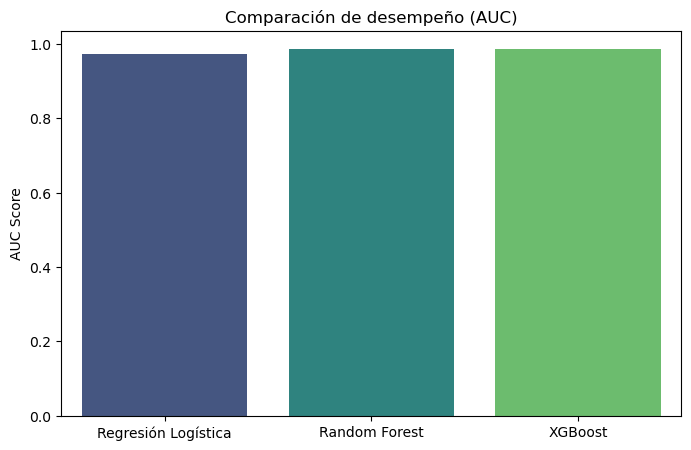

In [111]:
# ==========================================================
# 🚀 MODELOS OPTIMIZADOS SIN get_dummies
# ==========================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1️⃣ Dividir variables
# ==========================================================
df = base_balanceada_mod.copy()

# Variable objetivo
y = df['COMPENSADO'].astype(int)
X = df.drop(columns=['COMPENSADO'])

# Identificar variables numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ==========================================================
# 2️⃣ Preprocesadores
# ==========================================================
# Variables categóricas con baja cardinalidad (≤30)
cardinalidades = X_train[cat_cols].nunique().sort_values()
low_cat = cardinalidades[cardinalidades <= 30].index.tolist()
high_cat = cardinalidades[cardinalidades > 30].index.tolist()

# Para Regresión Logística
pre_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), low_cat)
    ],
    remainder='drop'
)

# Para modelos de árboles (RF, XGB)
pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop'
)

# ==========================================================
# 3️⃣ Definición de pipelines y grids
# ==========================================================
pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('prep', pre_tree),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_xgb = Pipeline([
    ('prep', pre_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist'))
])

# Parámetros
grid_lr = {'clf__C': [0.1, 1, 10], 'clf__solver': ['lbfgs', 'liblinear']}
grid_rf = {'clf__n_estimators': [100, 200], 'clf__max_depth': [8, 12], 'clf__min_samples_split': [2, 5]}
grid_xgb = {'clf__n_estimators': [200, 300], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [4, 6, 8]}

# ==========================================================
# 4️⃣ Entrenamiento y validación
# ==========================================================
def entrenar_y_evaluar(modelo, grid, nombre):
    search = GridSearchCV(modelo, grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print("Mejores hiperparámetros:", search.best_params_)
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    return roc_auc_score(y_test, y_proba)

auc_lr  = entrenar_y_evaluar(pipe_lr,  grid_lr,  "Regresión Logística")
auc_rf  = entrenar_y_evaluar(pipe_rf,  grid_rf,  "Random Forest")
auc_xgb = entrenar_y_evaluar(pipe_xgb, grid_xgb, "XGBoost")

# ==========================================================
# 5️⃣ Comparación gráfica
# ==========================================================
modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8,5))
sns.barplot(x=modelos, y=auc_scores, palette='viridis')
plt.title('Comparación de desempeño (AUC)')
plt.ylabel('AUC Score')
plt.show()


Numéricas: 8
Categóricas: 11

Distribución y_train ANTES del balanceo (%):
COMPENSADO
0    95.232031
1     4.767969
Name: proportion, dtype: float64

Distribución y_train DESPUÉS del balanceo (2:1) (%):
__y__
0    66.666667
1    33.333333
Name: proportion, dtype: float64
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Regresión Logística ===
Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
AUC: 0.9745478700545306
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    412455
           1       0.29      0.92      0.44     20650

    accuracy                           0.89    433105
   macro avg       0.64      0.90      0.69    433105
weighted avg       0.96      0.89      0.92    433105

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Random Forest ===
Mejores hiperparámetros: {'clf__max_depth': 12, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
AUC: 0.9862260710046495
              

C:\Users\fabil\AppData\Local\Temp\ipykernel_28020\918992069.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=auc_scores, palette='viridis')


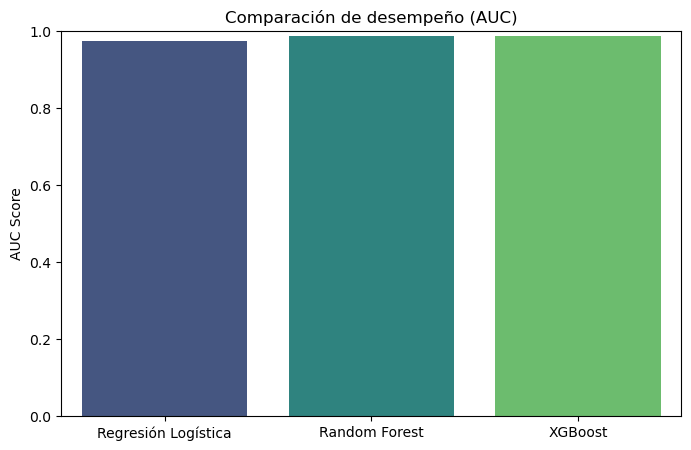

In [119]:
# ==========================================================
# 🚀 MODELOS OPTIMIZADOS SIN get_dummies
# ==========================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample  # <-- añadido para balanceo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1️⃣ Dividir variables
# ==========================================================
df = base_final_limpia.copy()  # <-- ahora usa la base sin balancear

# Variable objetivo
y = df['COMPENSADO'].astype(int)
X = df.drop(columns=['COMPENSADO'])

# Identificar variables numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

# Separar entrenamiento y prueba (primero split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ======= Balanceo SOLO en entrenamiento (downsampling 2:1) =======
def balancear_downsample(X_tr, y_tr, ratio_mayor_a_menor=2, random_state=42):
    tmp = X_tr.copy()
    tmp['__y__'] = y_tr.values if hasattr(y_tr, 'values') else y_tr
    may = tmp[tmp['__y__'] == 0]
    men = tmp[tmp['__y__'] == 1]

    if len(men) == 0 or len(may) == 0:
        # Si no hay ambas clases, regresar sin cambios
        tmp = tmp.sample(frac=1, random_state=random_state).reset_index(drop=True)
        return tmp.drop(columns='__y__'), tmp['__y__']

    n_target_may = min(len(may), len(men) * ratio_mayor_a_menor)
    may_down = resample(may, replace=False, n_samples=n_target_may, random_state=random_state)

    bal = pd.concat([may_down, men]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return bal.drop(columns='__y__'), bal['__y__']

print("\nDistribución y_train ANTES del balanceo (%):")
print((y_train.value_counts(normalize=True) * 100).rename('proportion'))

X_train_bal, y_train_bal = balancear_downsample(X_train, y_train, ratio_mayor_a_menor=2, random_state=42)

print("\nDistribución y_train DESPUÉS del balanceo (2:1) (%):")
print((y_train_bal.value_counts(normalize=True) * 100).rename('proportion'))

# ==========================================================
# 2️⃣ Preprocesadores
# ==========================================================
# Variables categóricas con baja/alta cardinalidad, calculadas en el TRAIN BALANCEADO
if cat_cols:
    cardinalidades = X_train_bal[cat_cols].nunique().sort_values()
    low_cat = cardinalidades[cardinalidades <= 30].index.tolist()
    high_cat = cardinalidades[cardinalidades > 30].index.tolist()
else:
    low_cat, high_cat = [], []

# Para Regresión Logística
pre_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), low_cat)
    ],
    remainder='drop'
)

# Para modelos de árboles (RF, XGB)
pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop'
)

# ==========================================================
# 3️⃣ Definición de pipelines y grids
# ==========================================================
pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('prep', pre_tree),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_xgb = Pipeline([
    ('prep', pre_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist'))
])

# Parámetros
grid_lr = {'clf__C': [0.1, 1, 10], 'clf__solver': ['lbfgs', 'liblinear']}
grid_rf = {'clf__n_estimators': [100, 200], 'clf__max_depth': [8, 12], 'clf__min_samples_split': [2, 5]}
grid_xgb = {'clf__n_estimators': [200, 300], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [4, 6, 8]}

# ==========================================================
# 4️⃣ Entrenamiento y validación
# ==========================================================
def entrenar_y_evaluar(modelo, grid, nombre):
    search = GridSearchCV(modelo, grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
    search.fit(X_train_bal, y_train_bal)  # <-- ENTRENAR SOLO CON TRAIN BALANCEADO
    best = search.best_estimator_
    y_pred = best.predict(X_test)         # <-- EVALUAR EN TEST SIN TOCAR
    y_proba = best.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print("Mejores hiperparámetros:", search.best_params_)
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    return roc_auc_score(y_test, y_proba)

auc_lr  = entrenar_y_evaluar(pipe_lr,  grid_lr,  "Regresión Logística")
auc_rf  = entrenar_y_evaluar(pipe_rf,  grid_rf,  "Random Forest")
auc_xgb = entrenar_y_evaluar(pipe_xgb, grid_xgb, "XGBoost")

# ==========================================================
# 5️⃣ Comparación gráfica
# ==========================================================
modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8,5))
sns.barplot(x=modelos, y=auc_scores, palette='viridis')
plt.title('Comparación de desempeño (AUC)')
plt.ylabel('AUC Score')
plt.ylim(0.0, 1.0)
plt.show()

C:\Users\fabil\AppData\Local\Temp\ipykernel_28020\589265882.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=frac_extra, random_state=42))


Periodo train: 2025-7 (+30% de 2025-8) | filas: 130079
Periodo test : 2025-8  | filas: 76423
Numéricas: 8
Categóricas: 10
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Regresión Logística ===
Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
AUC: 0.9758457474829657
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     48144
           1       0.84      0.93      0.88     28279

    accuracy                           0.91     76423
   macro avg       0.90      0.91      0.90     76423
weighted avg       0.91      0.91      0.91     76423

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Random Forest ===
Mejores hiperparámetros: {'clf__max_depth': 12, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
AUC: 0.9866921834453027
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     48144
           1       0.85      0.98      0.91     28279



C:\Users\fabil\AppData\Local\Temp\ipykernel_28020\589265882.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=auc_scores, palette='viridis')


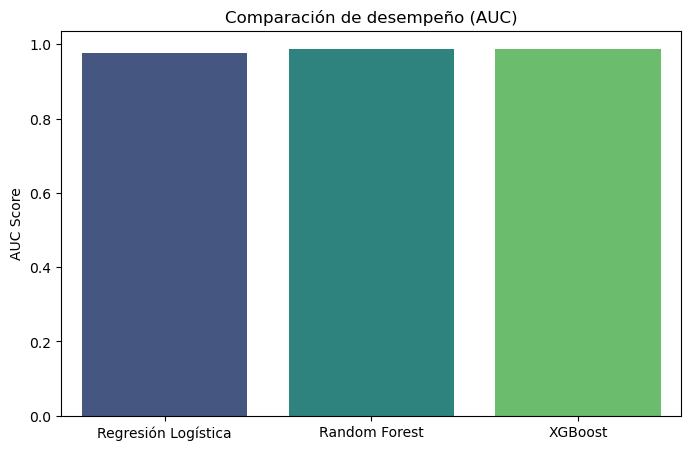

In [116]:
# ==========================================================
# 🚀 MODELOS OPTIMIZADOS SIN get_dummies (SPLIT POR PERÍODO)
# ==========================================================
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1️⃣ División temporal (train = periodo más antiguo + % del más reciente)
# ==========================================================
df = base_balanceada_mod.copy()

# Normalizar formato del periodo y elegir el más viejo para train y el más nuevo para test
df['PERIODO_STR'] = df['PERIODO'].astype(str).str.replace('_', '-')
periodos_ordenados = sorted(df['PERIODO_STR'].unique())

if len(periodos_ordenados) < 2:
    raise ValueError("Se requieren al menos 2 periodos distintos para hacer split temporal.")

train_period = periodos_ordenados[0]   # p.ej. '2025-7' o '2025-07'
test_period  = periodos_ordenados[-1]  # p.ej. '2025-8' o '2025-08'

train_df = df[df['PERIODO_STR'] == train_period].copy()
test_df  = df[df['PERIODO_STR'] == test_period].copy()

# ✅ Agregar fracción del test al train (estratificado por COMPENSADO)
frac_extra = 0.30  # <-- ajusta aquí el porcentaje (0.1 a 0.3 recomendado)
extra_sample = (
    test_df.groupby('COMPENSADO', group_keys=False)
           .apply(lambda g: g.sample(frac=frac_extra, random_state=42))
)
train_df = pd.concat([train_df, extra_sample], axis=0).reset_index(drop=True)
test_df = test_df.drop(index=extra_sample.index)

print(f"Periodo train: {train_period} (+{frac_extra*100:.0f}% de {test_period}) | filas: {len(train_df)}")
print(f"Periodo test : {test_period}  | filas: {len(test_df)}")

# y y X (evitar que PERIODO entre como predictor)
y_train = train_df['COMPENSADO'].astype(int)
X_train = train_df.drop(columns=['COMPENSADO', 'PERIODO', 'PERIODO_STR'], errors='ignore')

y_test = test_df['COMPENSADO'].astype(int)
X_test = test_df.drop(columns=['COMPENSADO', 'PERIODO', 'PERIODO_STR'], errors='ignore')

# Identificar variables numéricas y categóricas desde el TRAIN (robusto)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

# ==========================================================
# 2️⃣ Preprocesadores (igual que antes)
# ==========================================================
cardinalidades = X_train[cat_cols].nunique().sort_values()
low_cat = cardinalidades[cardinalidades <= 30].index.tolist()
high_cat = cardinalidades[cardinalidades > 30].index.tolist()

pre_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), low_cat)
    ],
    remainder='drop'
)

pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop'
)

# ==========================================================
# 3️⃣ Pipelines y grids (igual que antes)
# ==========================================================
pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('prep', pre_tree),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_xgb = Pipeline([
    ('prep', pre_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist'))
])

grid_lr  = {'clf__C': [0.1, 1, 10], 'clf__solver': ['lbfgs', 'liblinear']}
grid_rf  = {'clf__n_estimators': [100, 200], 'clf__max_depth': [8, 12], 'clf__min_samples_split': [2, 5]}
grid_xgb = {'clf__n_estimators': [200, 300], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [4, 6, 8]}

# ==========================================================
# 4️⃣ Entrenamiento y validación (igual que antes)
# ==========================================================
def entrenar_y_evaluar(modelo, grid, nombre):
    search = GridSearchCV(modelo, grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print("Mejores hiperparámetros:", search.best_params_)
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    return roc_auc_score(y_test, y_proba)

auc_lr  = entrenar_y_evaluar(pipe_lr,  grid_lr,  "Regresión Logística")
auc_rf  = entrenar_y_evaluar(pipe_rf,  grid_rf,  "Random Forest")
auc_xgb = entrenar_y_evaluar(pipe_xgb, grid_xgb, "XGBoost")

# ==========================================================
# 5️⃣ Comparación gráfica (igual que antes)
# ==========================================================
modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8,5))
sns.barplot(x=modelos, y=auc_scores, palette='viridis')
plt.title('Comparación de desempeño (AUC)')
plt.ylabel('AUC Score')
plt.show()